Lets Start

## 2. Import Libraries

In [69]:
# -- Standard Library ------------------------------------------
import warnings
warnings.filterwarnings('ignore')
import os, pickle

# -- Data Manipulation -----------------------------------------
import numpy as np
import pandas as pd

# -- Visualisation ---------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.gridspec import GridSpec

# -- Scikit-learn ----------------------------------------------
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_regression

# -- Gradient Boosting Models ----------------------------------
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# -- Display Settings ------------------------------------------
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
PALETTE = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800','#00BCD4','#F44336']
SEED = 42
np.random.seed(SEED)

print("[OK] All libraries loaded successfully.")
print(f"   NumPy     : {np.__version__}")
print(f"   Pandas    : {pd.__version__}")


[OK] All libraries loaded successfully.
   NumPy     : 1.26.4
   Pandas    : 2.3.3


## 3. Load Dataset

In [70]:
# -- Load the synthetic airline ground operations dataset ------
DATA_PATH = 'airline_ground_ops_dataset.csv'
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

# Parse datetime columns
datetime_cols = ['scheduled_arrival_time', 'scheduled_departure_time',
                 'actual_on_block_time', 'actual_off_block_time']
for col in datetime_cols:
    df[col] = pd.to_datetime(df[col])

from sklearn.preprocessing import QuantileTransformer

target_col = 'actual_turnaround_minutes'
target_raw = df[target_col].astype(float).copy()

# ✅ STEP 1: Apply hard floor BEFORE normalization (fixes the left-side spike)
hard_min_turnaround = 75.0
_, hi = target_raw.quantile([0.01, 0.99])
below_75_before = int((target_raw < hard_min_turnaround).sum())
target_floored = target_raw.clip(lower=hard_min_turnaround, upper=hi)

# ✅ STEP 2: Normalize the already-clipped target
qt = QuantileTransformer(
    output_distribution='normal',
    n_quantiles=min(1000, len(df)),
    random_state=SEED,
    subsample=int(1e9),
)
target_z = qt.fit_transform(target_floored.to_frame()).ravel()

# Rescale back to minute-like scale
target_norm = target_z * target_floored.std(ddof=0) + target_floored.mean()

df['actual_turnaround_minutes_raw'] = target_raw
df[target_col] = target_norm.round(1)
below_75_after = int((df[target_col] < hard_min_turnaround).sum())

# Numerical feature normalization (unchanged)
num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = {target_col, 'actual_turnaround_minutes_raw'}
continuous_num_cols = [
    c for c in num_cols_all
    if c not in exclude_cols and df[c].nunique(dropna=True) > 20
]

if continuous_num_cols:
    qt_num = QuantileTransformer(
        output_distribution='normal',
        n_quantiles=min(1000, len(df)),
        random_state=SEED,
        subsample=int(1e9),
    )
    num_raw = df[continuous_num_cols].astype(float).copy()
    num_z = qt_num.fit_transform(num_raw)
    num_scaled = num_z * num_raw.std(ddof=0).values + num_raw.mean().values

    q_lo = num_raw.quantile(0.01)
    q_hi = num_raw.quantile(0.99)
    num_scaled_df = pd.DataFrame(num_scaled, columns=continuous_num_cols, index=df.index)
    for c in continuous_num_cols:
        df[c] = np.clip(num_scaled_df[c], q_lo[c], q_hi[c])

print(f"[OK] Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(
    f"[OK] Target normalized: skew {target_raw.skew():.3f} -> "
    f"{df[target_col].skew():.3f}"
)
print(
    f"[OK] Turnaround outlier floor applied at 75 min: "
    f"{below_75_before} values clipped before normalization -> {below_75_after} remaining below 75"
)

if continuous_num_cols:
    before_skew = df_raw[continuous_num_cols].skew().abs().mean()
    after_skew = df[continuous_num_cols].skew().abs().mean()
    print(
        f"[OK] Continuous numerical features normalized: "
        f"mean |skew| {before_skew:.3f} -> {after_skew:.3f} "
        f"across {len(continuous_num_cols)} columns"
    )

df.head(3)


[OK] Dataset loaded: 10,000 rows × 44 columns
[OK] Target normalized: skew 0.461 -> -0.833
[OK] Turnaround outlier floor applied at 75 min: 232 values clipped before normalization -> 575 remaining below 75
[OK] Continuous numerical features normalized: mean |skew| 0.844 -> 0.321 across 23 columns


,flight_id,airline_code,flight_type,aircraft_type,arrival_airport,departure_airport,gate_type,scheduled_arrival_time,scheduled_departure_time,planned_turnaround_minutes,actual_on_block_time,unloading_start_delay_minutes,unloading_duration_minutes,loading_duration_minutes,fueling_duration_minutes,cleaning_duration_minutes,catering_duration_minutes,security_check_duration_minutes,cargo_weight_kg,cargo_volume_cbm,number_of_uld_containers,special_cargo_flag,hazardous_goods_flag,assigned_ground_crew_count,available_ground_crew_count,average_crew_experience_years,crew_utilization_percent,airport_congestion_index,gate_occupancy_percent,equipment_availability_percent,simultaneous_flights_at_terminal,weather_condition,visibility_km,wind_speed_kmh,weather_severity_score,maintenance_required_flag,maintenance_delay_minutes,aircraft_avg_turnaround_minutes,gate_avg_turnaround_minutes,airline_avg_turnaround_minutes,actual_turnaround_minutes,actual_off_block_time,turnaround_delay_minutes,actual_turnaround_minutes_raw
0,FL000001,SpiceJet,Domestic,B777,HYD,BLR,Contact,2024-07-19 15:30:00,2024-07-19 17:06:00,91.662,2024-07-19 15:51:00,1.638,30.958,44.712,34.416,29.866,15.410,8,18717.698,20.400,3,0,0,15,14.230,3.285,91.985,6,50.632,94.292,12.209,Clear,16.152,0.300,0.000,0,0.000,80.286,76.949,62.649,138.700,2024-07-19 18:11:00,44.728,140.000
1,FL000002,United,Domestic,A320,CCU,DEL,Remote,2024-06-26 15:15:00,2024-06-26 16:02:00,44.441,2024-06-26 15:05:00,2.961,19.526,25.313,20.941,6.000,6.664,11,7415.556,6.336,1,0,0,8,4.712,6.019,100.000,7,56.712,90.920,15.594,Clear,24.331,7.172,1.497,0,0.000,34.800,66.078,78.843,108.300,2024-06-26 16:48:00,57.717,103.000
2,FL000003,Singapore,Domestic,A321,CCU,HYD,Contact,2024-05-25 14:30:00,2024-05-25 15:29:00,65.921,2024-05-25 14:50:00,1.638,20.958,22.866,13.420,13.418,11.910,5,9247.387,10.201,1,0,0,9,9.749,10.790,83.338,6,51.534,100.000,11.272,Clear,29.700,0.300,0.000,0,0.000,56.434,62.541,77.461,-37.200,2024-05-25 15:57:00,17.000,67.000


## 4. Initial Data Inspection

In [71]:
# -- Shape & Columns ------------------------------------------
print("=" * 55)
print(f"  Dataset Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print("=" * 55)
print("\nColumn List:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col}")


  Dataset Shape : 10,000 rows × 44 columns

Column List:
   1. flight_id
   2. airline_code
   3. flight_type
   4. aircraft_type
   5. arrival_airport
   6. departure_airport
   7. gate_type
   8. scheduled_arrival_time
   9. scheduled_departure_time
  10. planned_turnaround_minutes
  11. actual_on_block_time
  12. unloading_start_delay_minutes
  13. unloading_duration_minutes
  14. loading_duration_minutes
  15. fueling_duration_minutes
  16. cleaning_duration_minutes
  17. catering_duration_minutes
  18. security_check_duration_minutes
  19. cargo_weight_kg
  20. cargo_volume_cbm
  21. number_of_uld_containers
  22. special_cargo_flag
  23. hazardous_goods_flag
  24. assigned_ground_crew_count
  25. available_ground_crew_count
  26. average_crew_experience_years
  27. crew_utilization_percent
  28. airport_congestion_index
  29. gate_occupancy_percent
  30. equipment_availability_percent
  31. simultaneous_flights_at_terminal
  32. weather_condition
  33. visibility_km
  34. wind_sp

In [72]:
# -- Data Types -----------------------------------------------
dtype_summary = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().mean() * 100).round(2).values,
    'Unique Values': df.nunique().values
})
print("Data Types & Missing Values Summary")
print("-" * 60)
dtype_summary


Data Types & Missing Values Summary
------------------------------------------------------------


,Column,Dtype,Non-Null Count,Null Count,Null %,Unique Values
0,flight_id,object,10000,0,0.000,10000
1,airline_code,object,10000,0,0.000,10
2,flight_type,object,10000,0,0.000,2
3,aircraft_type,object,10000,0,0.000,7
4,arrival_airport,object,10000,0,0.000,12
5,departure_airport,object,10000,0,0.000,12
6,gate_type,object,10000,0,0.000,2
7,scheduled_arrival_time,datetime64[ns],10000,0,0.000,8184
8,scheduled_departure_time,datetime64[ns],10000,0,0.000,9880
9,planned_turnaround_minutes,float64,10000,0,0.000,80


In [73]:
# -- Missing Values -------------------------------------------
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) == 0:
    print("[OK] No missing values found in the dataset.")
else:
    print(f"[WARN]  {len(missing)} columns with missing values:")
    print(missing)

# -- Duplicate Records -----------------------------------------
dupes = df.duplicated().sum()
print(f"\n[OK] Duplicate rows: {dupes}")

# -- Target Variable Quick Look --------------------------------
print(f"\nTarget - actual_turnaround_minutes")
print(f"  Min  : {df['actual_turnaround_minutes'].min():.0f} min")
print(f"  Max  : {df['actual_turnaround_minutes'].max():.0f} min")
print(f"  Mean : {df['actual_turnaround_minutes'].mean():.1f} min")
print(f"  Std  : {df['actual_turnaround_minutes'].std():.1f} min")


[OK] No missing values found in the dataset.

[OK] Duplicate rows: 0

Target - actual_turnaround_minutes
  Min  : -37 min
  Max  : 283 min
  Mean : 121.1 min
  Std  : 41.2 min


In [74]:
# -- Numerical Summary Statistics -----------------------------
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols].describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','50%'])


,count,mean,std,min,25%,50%,75%,max
planned_turnaround_minutes,10000.000000,70.519009,20.704696,40.000000,54.528363,69.342223,84.878233,123.000000
unloading_start_delay_minutes,10000.000000,2.822749,2.510047,0.000000,0.000000,2.960971,4.783516,13.000000
unloading_duration_minutes,10000.000000,23.479148,7.910291,9.000000,17.982784,23.269231,29.167228,41.000000
loading_duration_minutes,10000.000000,26.119313,9.129556,9.000000,20.102562,26.287421,32.431287,47.000000
fueling_duration_minutes,10000.000000,28.671307,10.353125,9.000000,20.940619,28.134152,35.699437,53.000000
cleaning_duration_minutes,10000.000000,19.449197,6.983483,6.000000,14.863562,19.479374,24.095166,36.000000
catering_duration_minutes,10000.000000,17.880877,8.109396,5.000000,11.910140,17.340856,23.720878,41.000000
security_check_duration_minutes,10000.000000,9.431800,3.122295,5.000000,7.000000,9.000000,12.000000,22.000000
cargo_weight_kg,10000.000000,10644.622703,3657.925265,3937.900000,8005.365194,10597.432361,13190.564495,19127.120000
cargo_volume_cbm,10000.000000,10.641242,3.854418,3.800000,7.819757,10.572110,13.279838,20.400000


## 5. Exploratory Data Analysis (EDA)

We explore the target variable, numerical features, categorical features, operational patterns, and correlations.

### 5.1 Target Variable Analysis - `actual_turnaround_minutes`


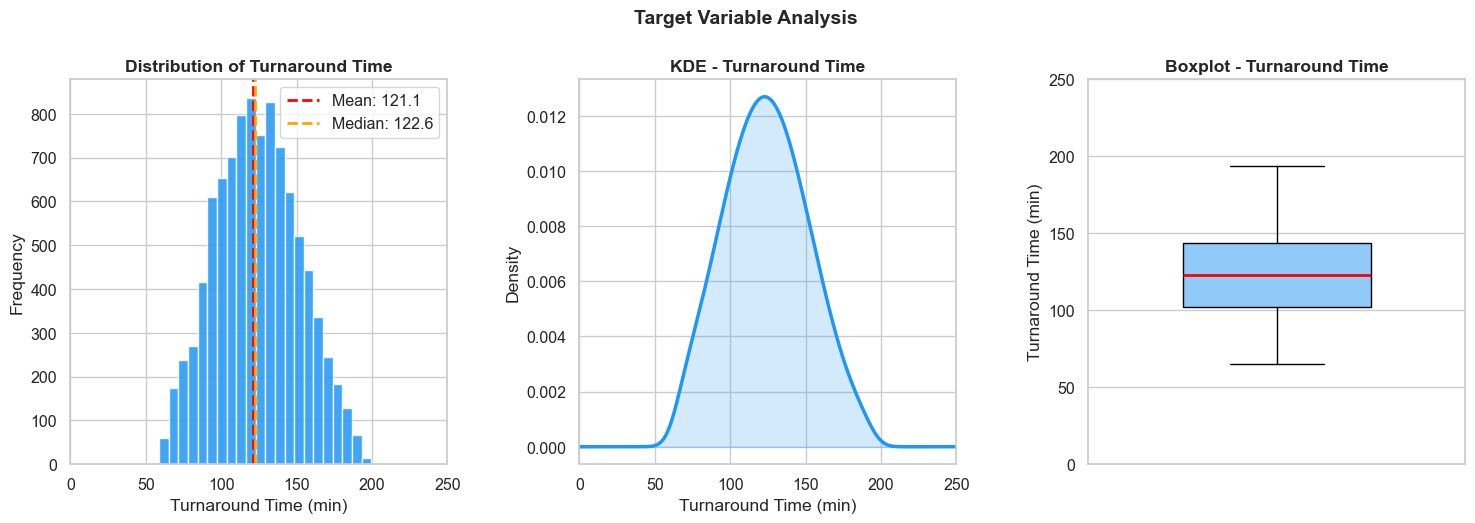

  Skewness  : -0.833  (left-skewed)
  Kurtosis  : 5.892
  Plot axis range fixed to: 0 to 200 min
  Actual data min/max     : -37.2 to 282.8 min


In [75]:
# -- Target Distribution: Histogram + KDE + Boxplot -----------
TARGET = 'actual_turnaround_minutes'
fig = plt.figure(figsize=(18, 5))
gs = GridSpec(1, 3, figure=fig, wspace=0.35)

# Histogram
ax1 = fig.add_subplot(gs[0])
ax1.hist(df[TARGET], bins=50, color='#2196F3', edgecolor='white', alpha=0.85)
ax1.axvline(df[TARGET].mean(), color='red', lw=2, ls='--', label=f"Mean: {df[TARGET].mean():.1f}")
ax1.axvline(df[TARGET].median(), color='orange', lw=2, ls='--', label=f"Median: {df[TARGET].median():.1f}")
ax1.set_title('Distribution of Turnaround Time', fontweight='bold')
ax1.set_xlabel('Turnaround Time (min)')
ax1.set_ylabel('Frequency')
ax1.set_xlim(0, 250)
ax1.legend()

# KDE
ax2 = fig.add_subplot(gs[1])
df[TARGET].plot.kde(ax=ax2, color='#2196F3', lw=2.5)
ax2.fill_between(ax2.lines[0].get_xdata(), ax2.lines[0].get_ydata(), alpha=0.2, color='#2196F3')
ax2.set_title('KDE - Turnaround Time', fontweight='bold')
ax2.set_xlabel('Turnaround Time (min)')
ax2.set_ylabel('Density')
ax2.set_xlim(0, 250)

# Boxplot
ax3 = fig.add_subplot(gs[2])
bp = ax3.boxplot(df[TARGET], patch_artist=True, widths=0.5,
                  medianprops=dict(color='red', lw=2),
                  boxprops=dict(facecolor='#90CAF9'))
ax3.set_title('Boxplot - Turnaround Time', fontweight='bold')
ax3.set_ylabel('Turnaround Time (min)')
ax3.set_ylim(0, 250)
ax3.set_xticks([])

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold', y=1.02)
# plt.savefig('target_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

# Statistics summary
skew = df[TARGET].skew()
kurt = df[TARGET].kurtosis()
print(f"  Skewness  : {skew:.3f}  ({'right-skewed' if skew > 0.5 else 'left-skewed' if skew < -0.5 else 'approx. symmetric'})")
print(f"  Kurtosis  : {kurt:.3f}")
print(f"  Plot axis range fixed to: 0 to 200 min")
print(f"  Actual data min/max     : {df[TARGET].min():.1f} to {df[TARGET].max():.1f} min")

In [124]:
dataset=df.to_csv('processed_airline_dataset.csv', index=False)

### 5.2 Numerical Feature Analysis

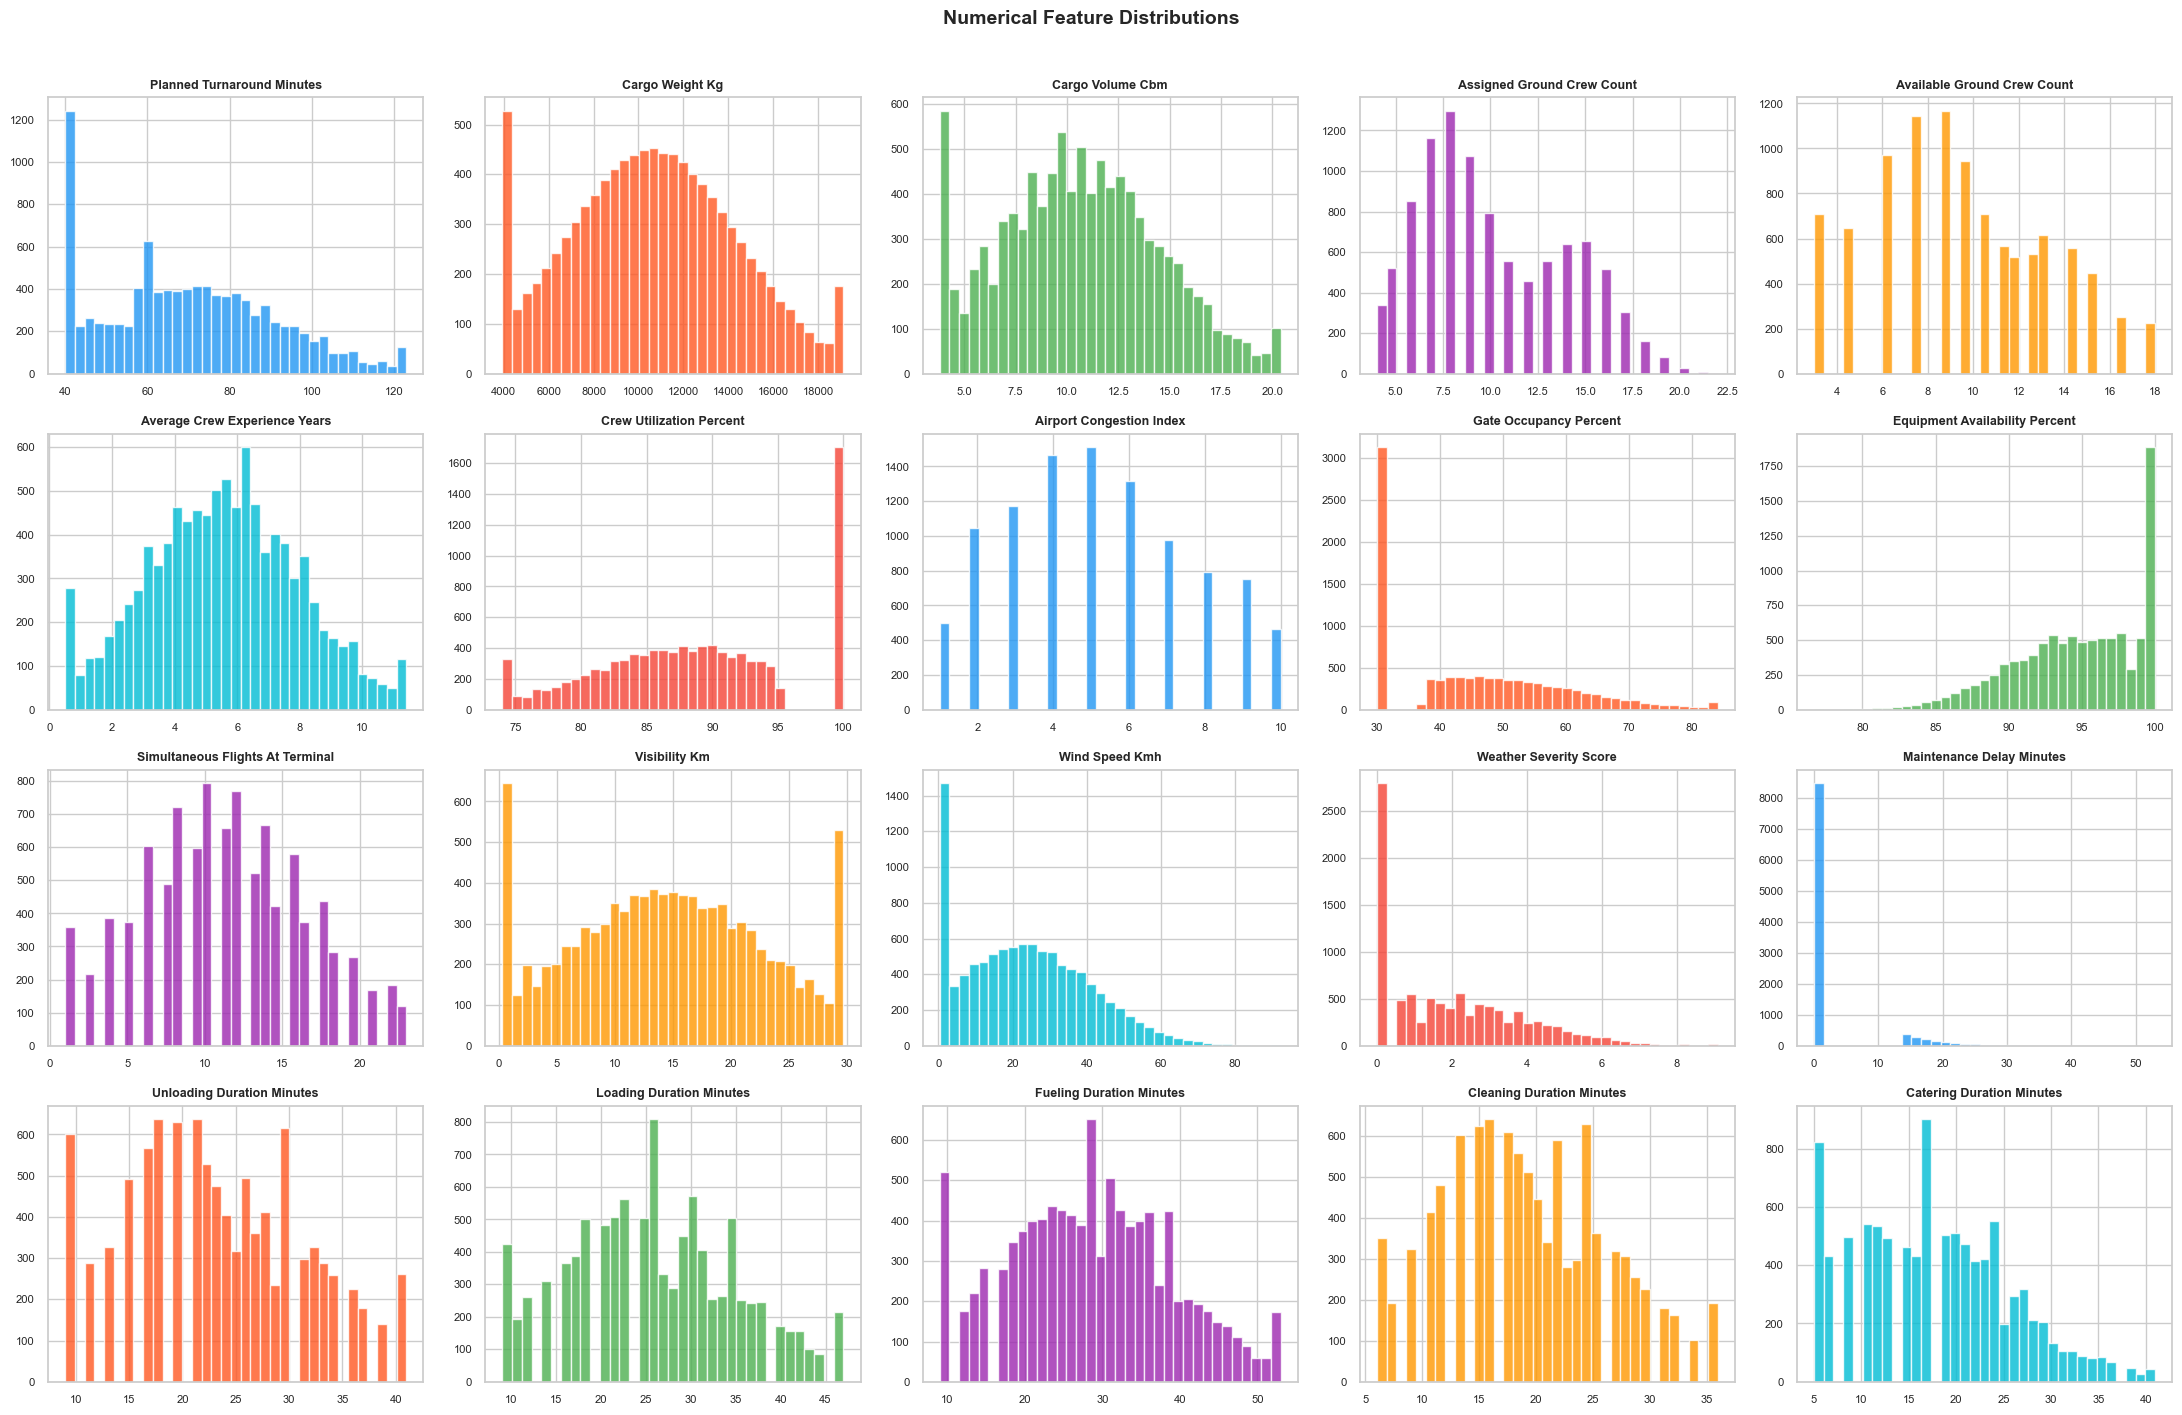

[OK] Numerical feature distributions plotted.


In [76]:
# -- Histograms for all key numerical features -----------------
num_features = [
    'planned_turnaround_minutes', 'cargo_weight_kg', 'cargo_volume_cbm',
    'assigned_ground_crew_count', 'available_ground_crew_count',
    'average_crew_experience_years', 'crew_utilization_percent',
    'airport_congestion_index', 'gate_occupancy_percent',
    'equipment_availability_percent', 'simultaneous_flights_at_terminal',
    'visibility_km', 'wind_speed_kmh', 'weather_severity_score',
    'maintenance_delay_minutes', 'unloading_duration_minutes',
    'loading_duration_minutes', 'fueling_duration_minutes',
    'cleaning_duration_minutes', 'catering_duration_minutes'
]

fig, axes = plt.subplots(4, 5, figsize=(22, 14))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=35, color=PALETTE[i % len(PALETTE)],
                 edgecolor='white', alpha=0.8)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=8)

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig('numerical_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print("[OK] Numerical feature distributions plotted.")


In [77]:
# -- Outlier Detection using IQR -------------------------------
outlier_report = []
for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({'Feature': col, 'Q1': Q1, 'Q3': Q3,
                           'IQR': IQR, 'Lower Fence': lower,
                           'Upper Fence': upper, 'Outlier Count': n_out,
                           'Outlier %': round(n_out / len(df) * 100, 2)})

outlier_df = pd.DataFrame(outlier_report).sort_values('Outlier %', ascending=False)
print("Outlier Summary (IQR Method):")
outlier_df[outlier_df['Outlier Count'] > 0][['Feature','Outlier Count','Outlier %','Lower Fence','Upper Fence']]


Outlier Summary (IQR Method):


,Feature,Outlier Count,Outlier %,Lower Fence,Upper Fence
14,maintenance_delay_minutes,1501,15.010,0.000,0.000
9,equipment_availability_percent,37,0.370,81.582,108.518
12,wind_speed_kmh,36,0.360,-27.617,72.759
13,weather_severity_score,21,0.210,-4.971,8.284


### 5.3 Categorical Feature Analysis

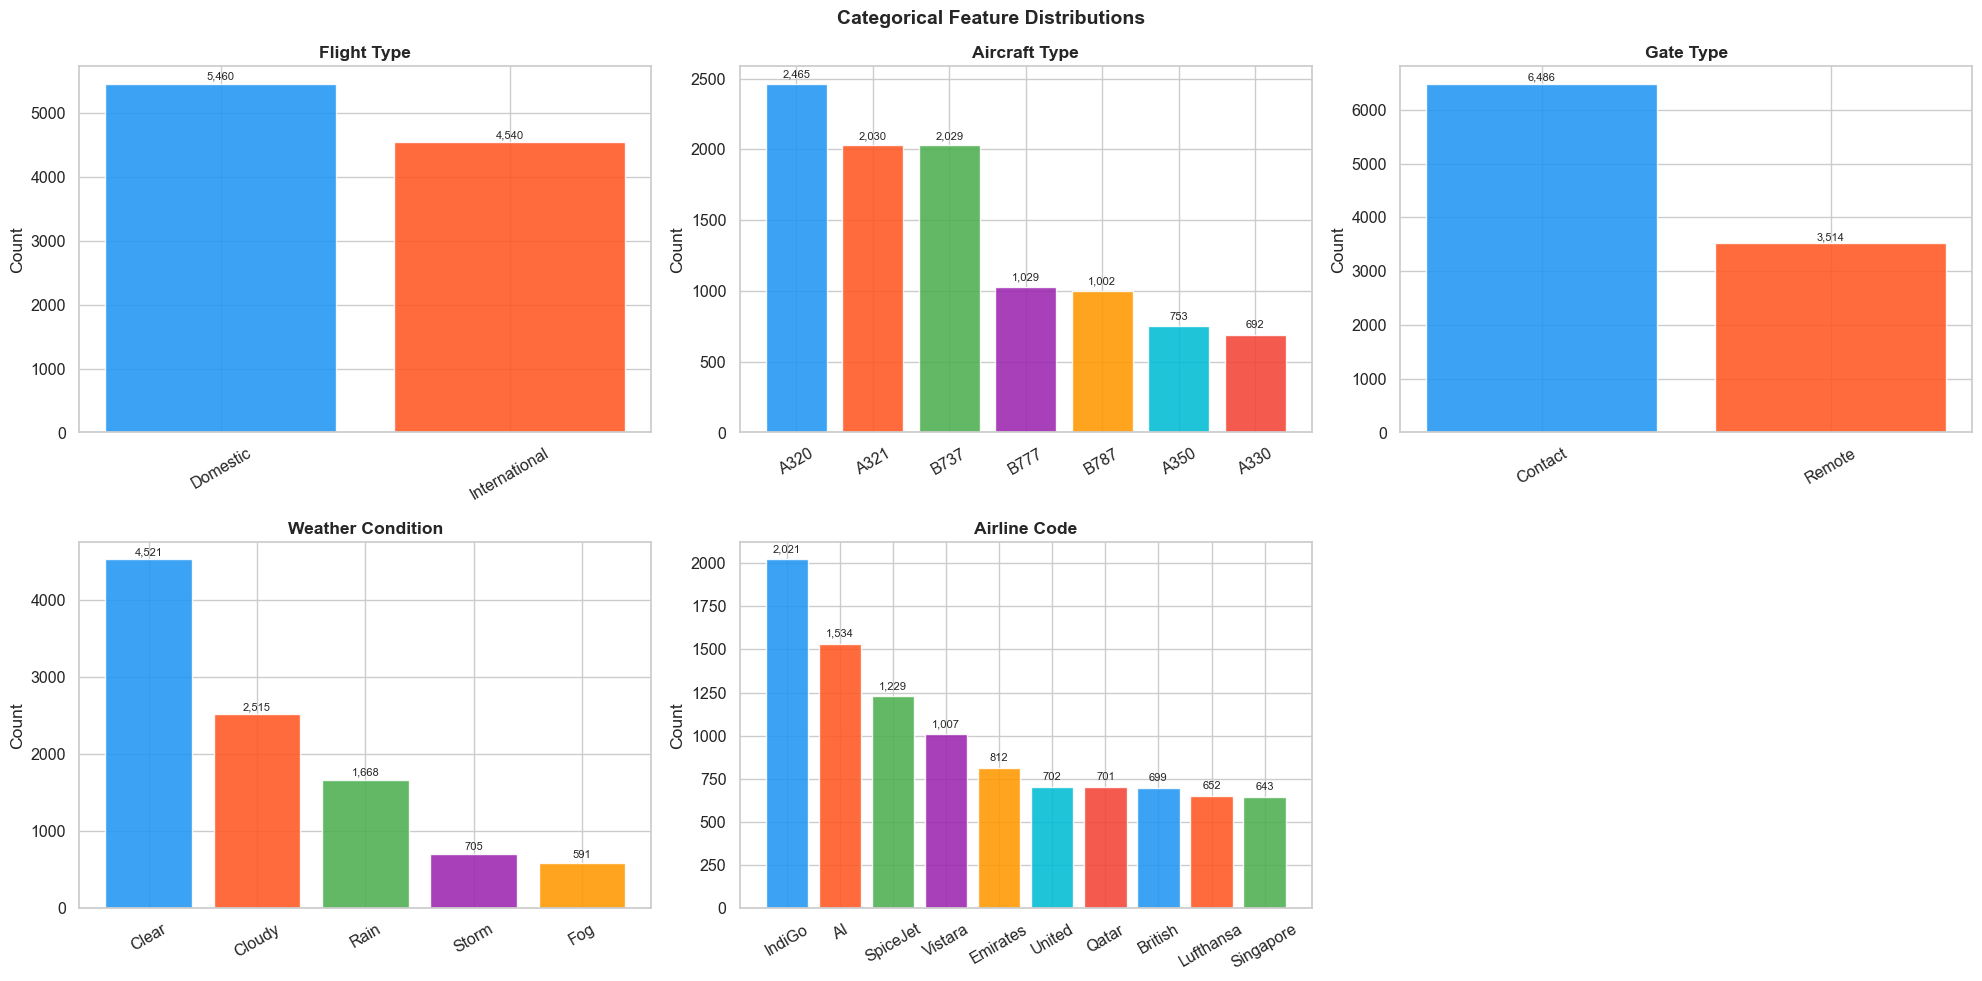


flight_type:
flight_type
Domestic        54.600
International   45.400 %

aircraft_type:
aircraft_type
A320   24.600
A321   20.300
B737   20.300
B777   10.300
B787   10.000
A350    7.500
A330    6.900 %

gate_type:
gate_type
Contact   64.900
Remote    35.100 %

weather_condition:
weather_condition
Clear    45.200
Cloudy   25.200
Rain     16.700
Storm     7.000
Fog       5.900 %


In [78]:
# -- Count Plots for categorical features ----------------------
cat_features = ['flight_type', 'aircraft_type', 'gate_type', 'weather_condition',
                'airline_code']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    vc = df[col].value_counts()
    bars = axes[i].bar(vc.index, vc.values, color=PALETTE[:len(vc)], edgecolor='white', alpha=0.88)
    axes[i].set_title(f'{col.replace("_"," ").title()}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, vc.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                     f'{val:,}', ha='center', va='bottom', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('categorical_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

# Frequency tables
for col in ['flight_type', 'aircraft_type', 'gate_type', 'weather_condition']:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True).mul(100).round(1).to_string(), '%')


### 5.4 Operational Insights

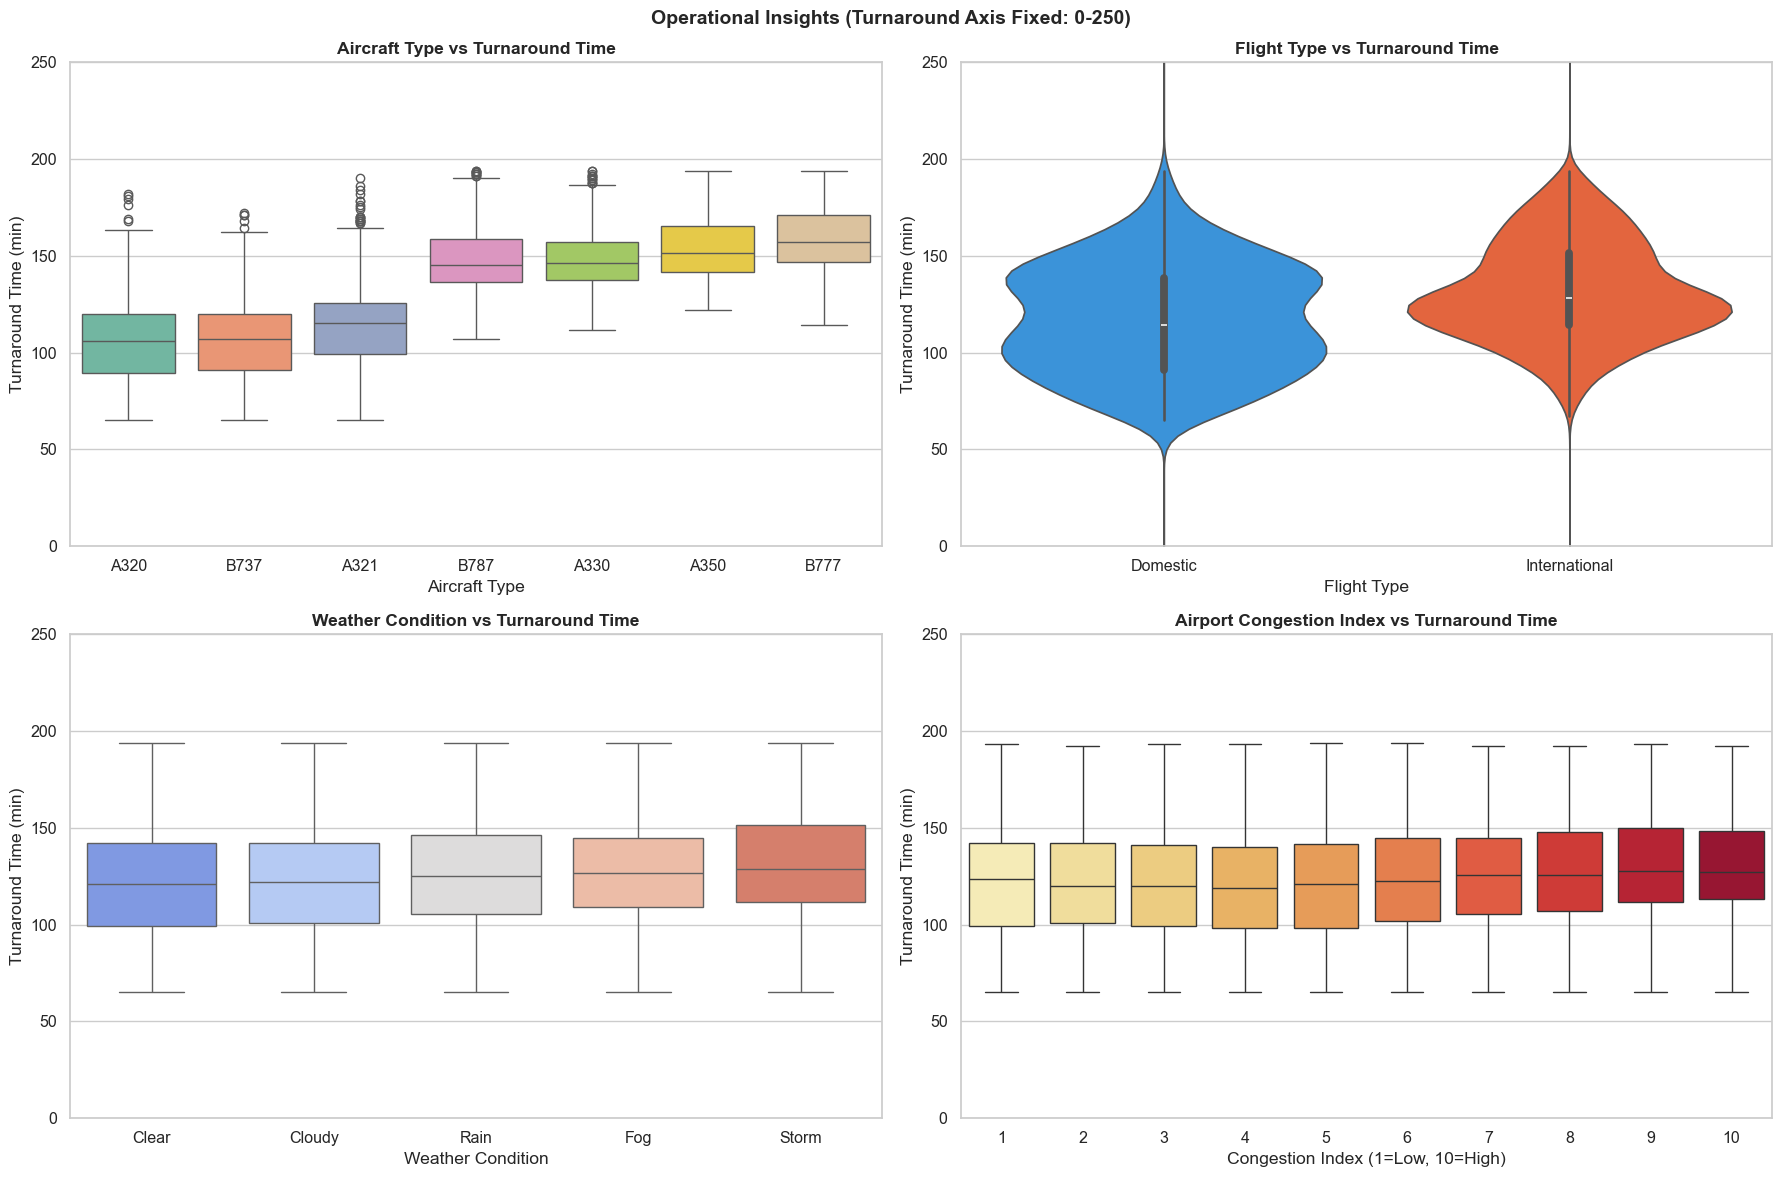

In [79]:
# -- Aircraft Type vs Turnaround Time -------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# A) Aircraft Type
order_ac = df.groupby('aircraft_type')['actual_turnaround_minutes'].median().sort_values().index
sns.boxplot(data=df, x='aircraft_type', y=TARGET, order=order_ac,
            palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Aircraft Type vs Turnaround Time', fontweight='bold')
axes[0, 0].set_xlabel('Aircraft Type')
axes[0, 0].set_ylabel('Turnaround Time (min)')
axes[0, 0].set_ylim(0, 250)

# B) Flight Type
sns.violinplot(data=df, x='flight_type', y=TARGET,
               palette=['#2196F3', '#FF5722'], inner='box', ax=axes[0, 1])
axes[0, 1].set_title('Flight Type vs Turnaround Time', fontweight='bold')
axes[0, 1].set_xlabel('Flight Type')
axes[0, 1].set_ylabel('Turnaround Time (min)')
axes[0, 1].set_ylim(0, 250)

# C) Weather Condition
order_wc = df.groupby('weather_condition')['actual_turnaround_minutes'].median().sort_values().index
sns.boxplot(data=df, x='weather_condition', y=TARGET, order=order_wc,
            palette='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title('Weather Condition vs Turnaround Time', fontweight='bold')
axes[1, 0].set_xlabel('Weather Condition')
axes[1, 0].set_ylabel('Turnaround Time (min)')
axes[1, 0].set_ylim(0, 250)

# D) Congestion Index
sns.boxplot(data=df, x='airport_congestion_index', y=TARGET,
            palette='YlOrRd', ax=axes[1, 1])
axes[1, 1].set_title('Airport Congestion Index vs Turnaround Time', fontweight='bold')
axes[1, 1].set_xlabel('Congestion Index (1=Low, 10=High)')
axes[1, 1].set_ylabel('Turnaround Time (min)')
axes[1, 1].set_ylim(0, 250)

plt.suptitle('Operational Insights (Turnaround Axis Fixed: 0-250)', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('operational_insights.png', bbox_inches='tight', dpi=150)
plt.show()

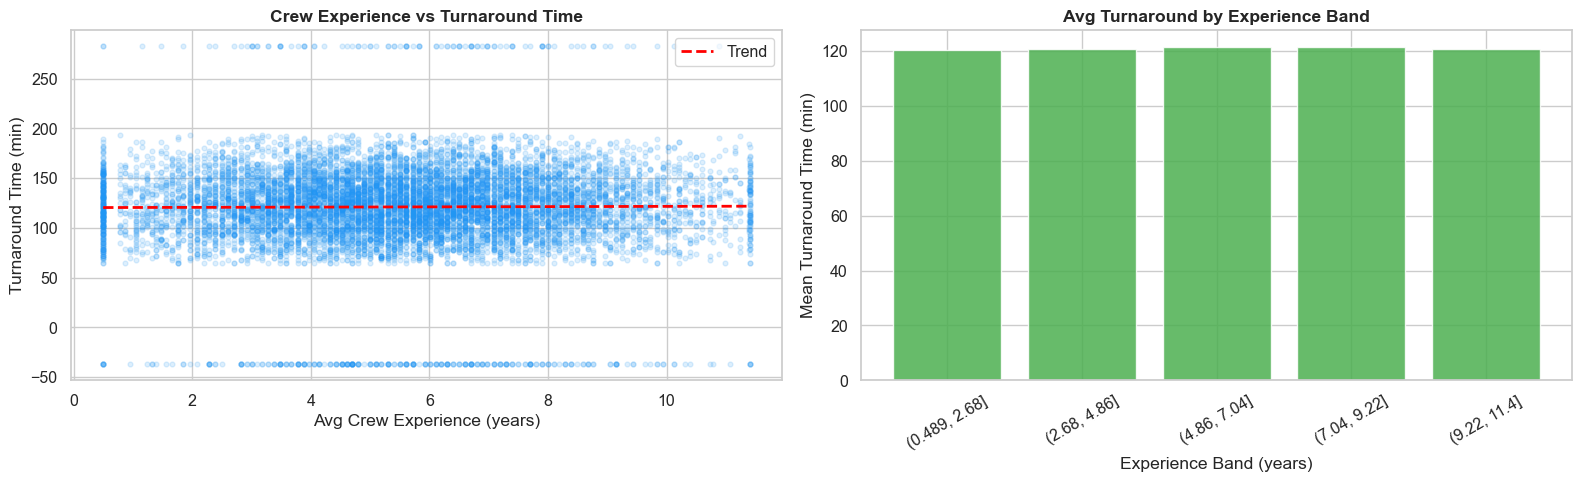

In [80]:
# -- Crew Experience vs Turnaround Time -----------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter with regression line
axes[0].scatter(df['average_crew_experience_years'], df[TARGET],
                alpha=0.15, s=12, color='#2196F3')
z = np.polyfit(df['average_crew_experience_years'], df[TARGET], 1)
p = np.poly1d(z)
xs = np.linspace(df['average_crew_experience_years'].min(),
                 df['average_crew_experience_years'].max(), 100)
axes[0].plot(xs, p(xs), color='red', lw=2, ls='--', label=f'Trend')
axes[0].set_title('Crew Experience vs Turnaround Time', fontweight='bold')
axes[0].set_xlabel('Avg Crew Experience (years)')
axes[0].set_ylabel('Turnaround Time (min)')
axes[0].legend()

# Binned view
df['exp_bin'] = pd.cut(df['average_crew_experience_years'], bins=5)
exp_grouped = df.groupby('exp_bin')[TARGET].mean().reset_index()
axes[1].bar([str(x) for x in exp_grouped['exp_bin']],
            exp_grouped[TARGET], color='#4CAF50', edgecolor='white', alpha=0.85)
axes[1].set_title('Avg Turnaround by Experience Band', fontweight='bold')
axes[1].set_xlabel('Experience Band (years)')
axes[1].set_ylabel('Mean Turnaround Time (min)')
axes[1].tick_params(axis='x', rotation=30)
df.drop('exp_bin', axis=1, inplace=True)

plt.tight_layout()
# plt.savefig('crew_experience_analysis.png', bbox_inches='tight', dpi=150)
plt.show()


### 5.5 Correlation Analysis

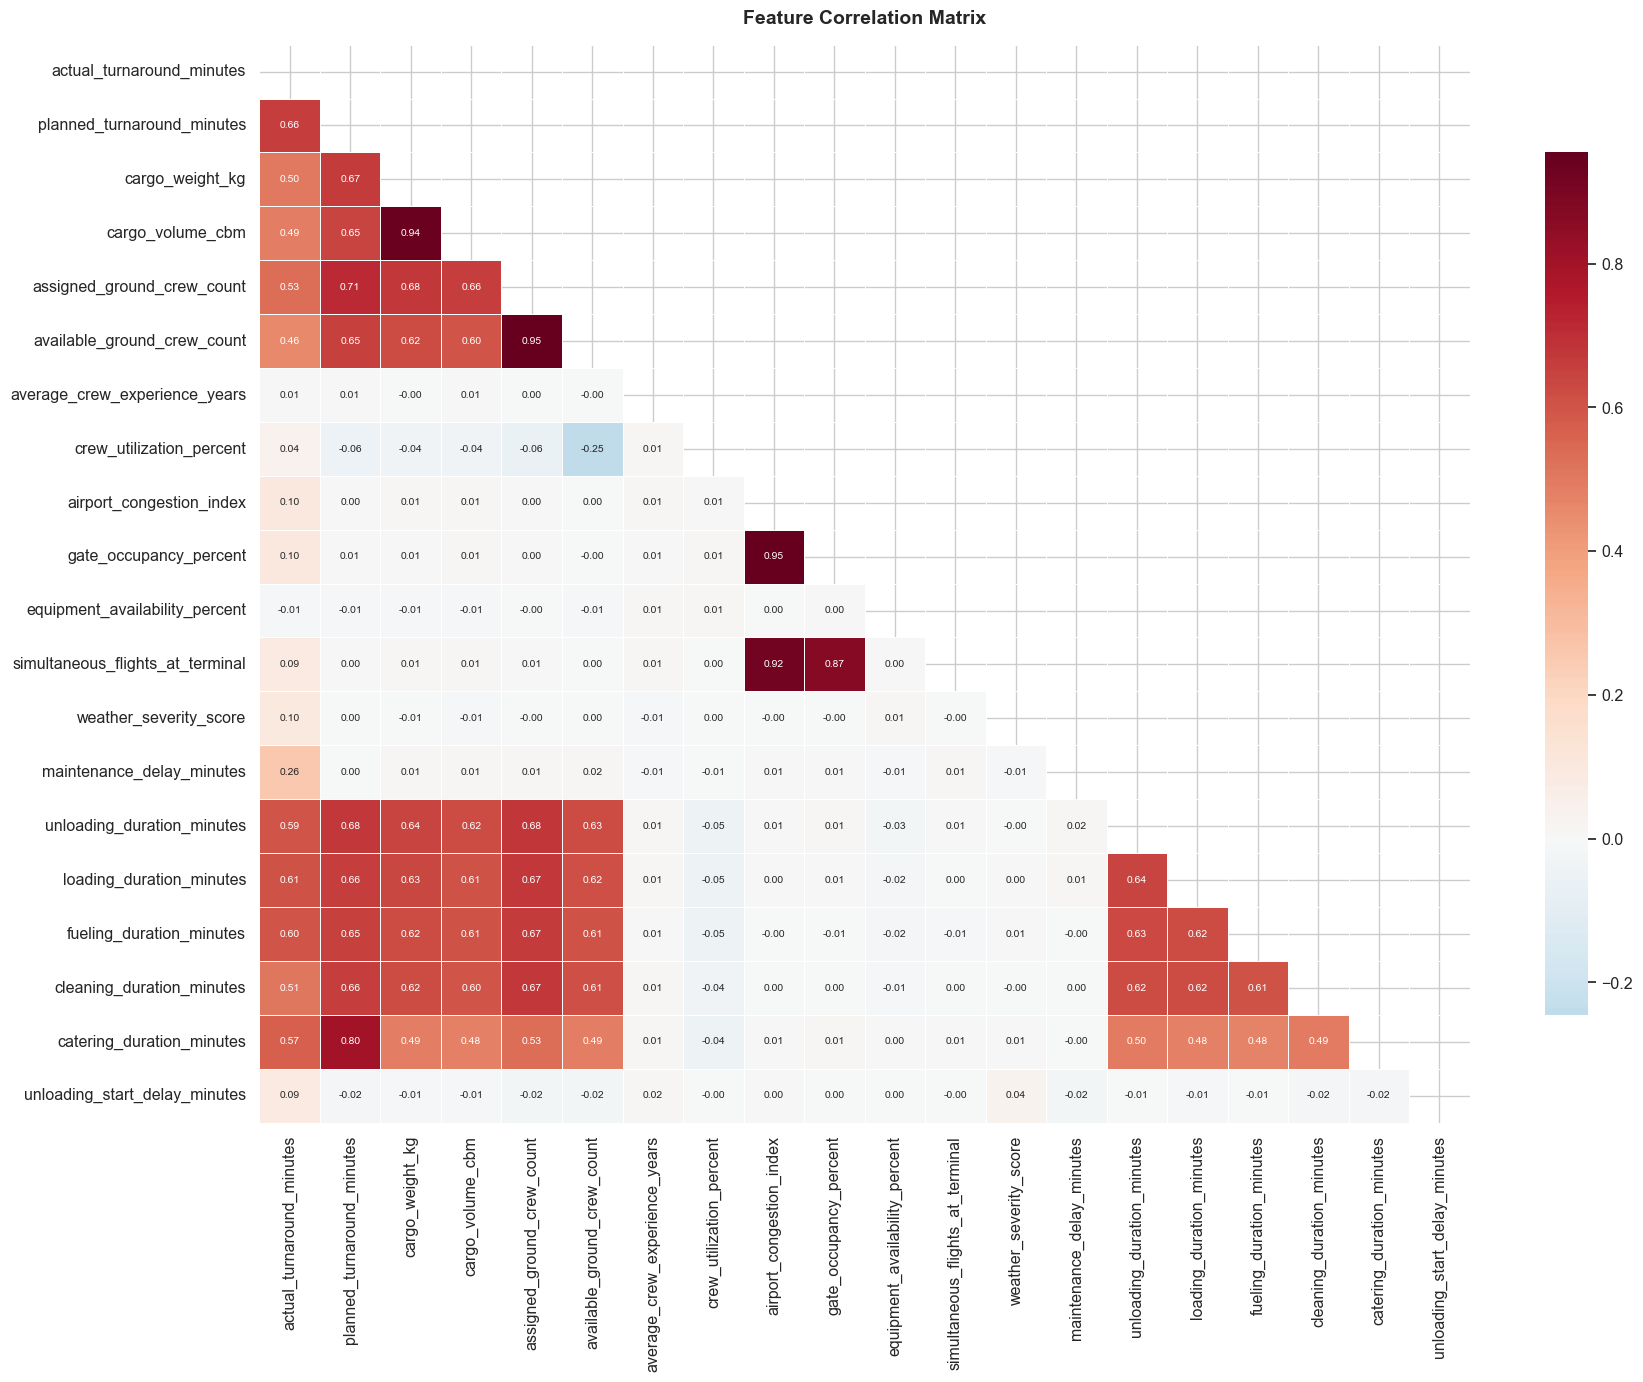

In [81]:
# -- Correlation Heatmap ---------------------------------------
corr_cols = [
    'actual_turnaround_minutes', 'planned_turnaround_minutes',
    'cargo_weight_kg', 'cargo_volume_cbm',
    'assigned_ground_crew_count', 'available_ground_crew_count',
    'average_crew_experience_years', 'crew_utilization_percent',
    'airport_congestion_index', 'gate_occupancy_percent',
    'equipment_availability_percent', 'simultaneous_flights_at_terminal',
    'weather_severity_score', 'maintenance_delay_minutes',
    'unloading_duration_minutes', 'loading_duration_minutes',
    'fueling_duration_minutes', 'cleaning_duration_minutes',
    'catering_duration_minutes', 'unloading_start_delay_minutes'
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            annot_kws={'size': 7.5}, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
# plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


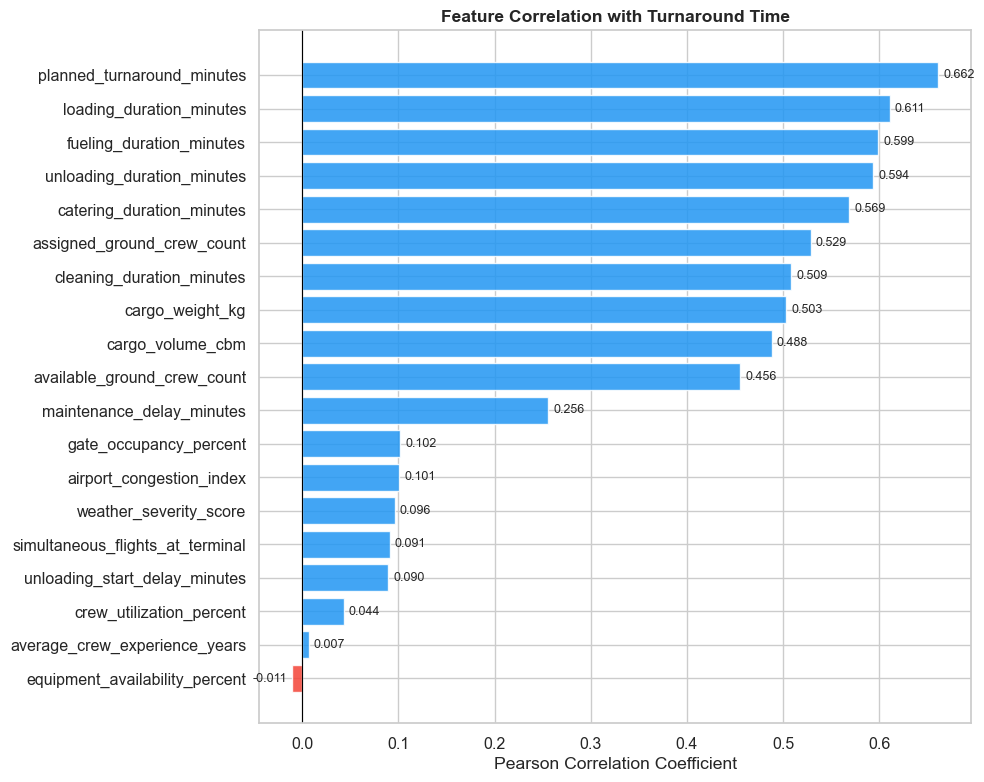


Top 10 features correlated with turnaround time:
                             actual_turnaround_minutes
planned_turnaround_minutes                       0.662
loading_duration_minutes                         0.611
fueling_duration_minutes                         0.599
unloading_duration_minutes                       0.594
catering_duration_minutes                        0.569
assigned_ground_crew_count                       0.529
cleaning_duration_minutes                        0.509
cargo_weight_kg                                  0.503
cargo_volume_cbm                                 0.488
available_ground_crew_count                      0.456


In [82]:
# -- Top Correlations with Target -----------------------------
target_corr = df[corr_cols].corr()[[TARGET]].drop(TARGET).sort_values(TARGET)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#F44336' if v < 0 else '#2196F3' for v in target_corr[TARGET]]
bars = ax.barh(target_corr.index, target_corr[TARGET], color=colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Feature Correlation with Turnaround Time', fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
for bar, val in zip(bars, target_corr[TARGET]):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
# plt.savefig('target_correlations.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nTop 10 features correlated with turnaround time:")
print(target_corr.abs().sort_values(TARGET, ascending=False).head(10))


### 5.6 Feature Importance Exploration - Mutual Information

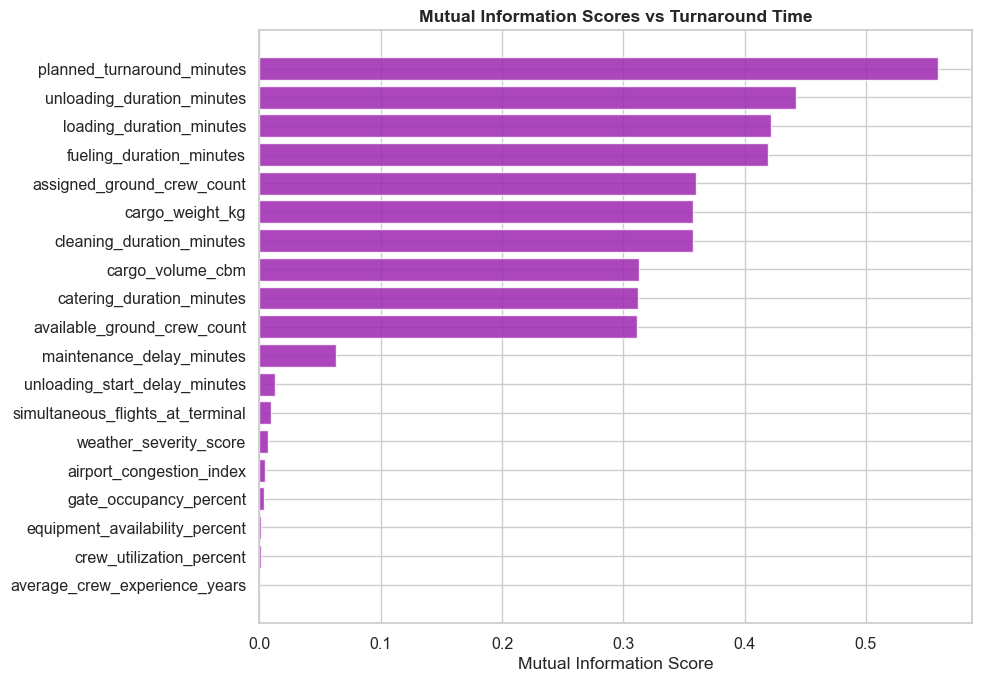

                         Feature  MI Score
      planned_turnaround_minutes     0.560
      unloading_duration_minutes     0.443
        loading_duration_minutes     0.421
        fueling_duration_minutes     0.420
      assigned_ground_crew_count     0.360
                 cargo_weight_kg     0.358
       cleaning_duration_minutes     0.357
                cargo_volume_cbm     0.313
       catering_duration_minutes     0.312
     available_ground_crew_count     0.311
       maintenance_delay_minutes     0.063
   unloading_start_delay_minutes     0.013
simultaneous_flights_at_terminal     0.010
          weather_severity_score     0.007
        airport_congestion_index     0.004
          gate_occupancy_percent     0.004
  equipment_availability_percent     0.002
        crew_utilization_percent     0.001
   average_crew_experience_years     0.000


In [83]:
# -- Mutual Information Scores ---------------------------------
mi_features = [c for c in corr_cols if c != TARGET]
mi_scores = mutual_info_regression(df[mi_features].fillna(0), df[TARGET], random_state=SEED)
mi_df = pd.DataFrame({'Feature': mi_features, 'MI Score': mi_scores}).sort_values('MI Score', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(mi_df['Feature'][::-1], mi_df['MI Score'][::-1],
        color='#9C27B0', edgecolor='white', alpha=0.85)
ax.set_title('Mutual Information Scores vs Turnaround Time', fontweight='bold')
ax.set_xlabel('Mutual Information Score')
plt.tight_layout()
# plt.savefig('mutual_information.png', bbox_inches='tight', dpi=150)
plt.show()
print(mi_df.to_string(index=False))


## 6. Feature Engineering

We engineer additional domain-relevant features from raw columns to improve model signal.


In [109]:
# -- 6.1 Datetime-Based Features -------------------------------
df['scheduled_arrival_hour']   = df['scheduled_arrival_time'].dt.hour
df['scheduled_departure_hour'] = df['scheduled_departure_time'].dt.hour
df['day_of_week']   = df['scheduled_arrival_time'].dt.dayofweek      # 0=Mon
df['month']         = df['scheduled_arrival_time'].dt.month
df['is_weekend']    = df['day_of_week'].isin([5, 6]).astype(int)
df['is_peak_hour']  = df['scheduled_arrival_hour'].between(7, 10).astype(int) |                       df['scheduled_arrival_hour'].between(17, 20).astype(int)

print("[OK] Datetime features created:", ['scheduled_arrival_hour','scheduled_departure_hour',
      'day_of_week','month','is_weekend','is_peak_hour'])


[OK] Datetime features created: ['scheduled_arrival_hour', 'scheduled_departure_hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour']


In [110]:
# -- 6.2 Operational Composite Features ------------------------

# Scheduled turnaround (from schedule)
df['scheduled_turnaround_minutes'] = (
    df['scheduled_departure_time'] - df['scheduled_arrival_time']
).dt.total_seconds() / 60

# Total sequential service time
df['total_service_duration'] = (
    df['unloading_duration_minutes'] + df['loading_duration_minutes'] +
    df['fueling_duration_minutes'] + df['cleaning_duration_minutes'] +
    df['catering_duration_minutes'] + df['security_check_duration_minutes']
)

# Total delay components
df['total_delay_minutes'] = (
    df['unloading_start_delay_minutes'] + df['maintenance_delay_minutes']
)

# Cargo density (weight per volume unit)
df['cargo_density'] = (df['cargo_weight_kg'] / (df['cargo_volume_cbm'] + 1)).round(2)

# Congestion score (combined congestion signals)
df['congestion_score'] = (
    df['airport_congestion_index'] * 0.4 +
    df['gate_occupancy_percent'] / 10 * 0.3 +
    df['simultaneous_flights_at_terminal'] / df['simultaneous_flights_at_terminal'].max() * 10 * 0.3
).round(2)

# Weather severity (combined weather signals)
df['weather_severity_composite'] = (
    df['weather_severity_score'] * 0.5 +
    (1 / (df['visibility_km'] + 0.1)).round(4) * 5 +
    df['wind_speed_kmh'] / df['wind_speed_kmh'].max() * 5
).round(2)

# Equipment availability score (0?1)
df['equipment_availability_score'] = (df['equipment_availability_percent'] / 100).round(3)

# Crew efficiency score: experience ? utilisation ratio
df['crew_efficiency_score'] = (
    df['average_crew_experience_years'] *
    (df['available_ground_crew_count'] / (df['assigned_ground_crew_count'] + 0.1))
).round(3)

# Terminal activity ratio (flights per gate capacity)
df['terminal_activity_ratio'] = (
    df['simultaneous_flights_at_terminal'] / (100 - df['gate_occupancy_percent'] + 1)
).round(3)

# Departure schedule tightness (deviation from plan)
df['schedule_tightness'] = (
    df['actual_turnaround_minutes'] - df['planned_turnaround_minutes']
)

# Special cargo burden flag
df['cargo_complexity_flag'] = (
    (df['special_cargo_flag'] + df['hazardous_goods_flag']).clip(0, 1)
)

engineered_features = [
    'scheduled_turnaround_minutes', 'total_service_duration', 'total_delay_minutes',
    'cargo_density', 'congestion_score', 'weather_severity_composite',
    'equipment_availability_score', 'crew_efficiency_score',
    'terminal_activity_ratio', 'schedule_tightness', 'cargo_complexity_flag',
    'is_peak_hour', 'is_weekend', 'day_of_week', 'month'
]

print(f"[OK] {len(engineered_features)} engineered features created:")
for f in engineered_features:
    print(f"   * {f}")
print(f"\nDataset shape after engineering: {df.shape}")


[OK] 15 engineered features created:
   * scheduled_turnaround_minutes
   * total_service_duration
   * total_delay_minutes
   * cargo_density
   * congestion_score
   * weather_severity_composite
   * equipment_availability_score
   * crew_efficiency_score
   * terminal_activity_ratio
   * schedule_tightness
   * cargo_complexity_flag
   * is_peak_hour
   * is_weekend
   * day_of_week
   * month

Dataset shape after engineering: (10000, 61)


In [111]:
# -- 6.3 Validate Engineered Features -------------------------
df[engineered_features].describe().T.round(3).style.background_gradient(cmap='Greens', subset=['mean'])


,count,mean,std,min,25%,50%,75%,max
scheduled_turnaround_minutes,10000.000000,69.543000,22.818000,40.000000,52.000000,62.000000,86.000000,126.000000
total_service_duration,10000.000000,125.032000,34.850000,54.044000,97.692000,112.928000,159.061000,214.067000
total_delay_minutes,10000.000000,5.597000,7.260000,0.000000,1.638000,2.961000,6.097000,62.304000
cargo_density,10000.000000,915.847000,116.036000,573.770000,829.710000,903.735000,997.562000,1259.730000
congestion_score,10000.000000,4.957000,1.998000,1.430000,3.330000,4.850000,6.400000,9.520000
weather_severity_composite,10000.000000,3.523000,3.998000,0.180000,1.400000,2.230000,4.200000,20.890000
equipment_availability_score,10000.000000,0.946000,0.043000,0.767000,0.917000,0.950000,0.984000,1.000000
crew_efficiency_score,10000.000000,5.218000,2.392000,0.218000,3.515000,5.147000,6.818000,12.248000
terminal_activity_ratio,10000.000000,0.256000,0.206000,0.014000,0.118000,0.202000,0.328000,1.361000
schedule_tightness,10000.000000,50.578000,31.604000,-111.237000,41.000000,52.579000,64.207000,202.670000


## 7. Data Preprocessing

Steps: Missing value handling ? Outlier treatment ? Feature selection ? Encoding ? Scaling ? Train-Test Split


In [112]:
# -- 7.1 Define Feature Sets -----------------------------------
# Drop identifiers, raw datetimes, and target leakage columns
DROP_COLS = [
    'flight_id', 'scheduled_arrival_time', 'scheduled_departure_time',
    'actual_on_block_time', 'actual_off_block_time',
    'actual_turnaround_minutes',   # this IS our target
    'turnaround_delay_minutes',    # post-hoc label ? leakage
    'schedule_tightness',          # uses target
    'aircraft_avg_turnaround_minutes', 'gate_avg_turnaround_minutes',
    'airline_avg_turnaround_minutes'   # keep as contextual signal only
]

TARGET = 'actual_turnaround_minutes'
df_model = df.copy()

# Restore historical averages (informative, not leakage)
for col in ['aircraft_avg_turnaround_minutes', 'gate_avg_turnaround_minutes',
            'airline_avg_turnaround_minutes']:
    df_model[col] = df[col]

# Feature matrix
feature_cols = [c for c in df_model.columns if c not in DROP_COLS + [TARGET,
                'turnaround_delay_minutes', 'schedule_tightness',
                'scheduled_arrival_time', 'scheduled_departure_time',
                'actual_on_block_time', 'actual_off_block_time', 'flight_id']]

X = df_model[feature_cols].copy()
y = df_model[TARGET].copy()

print(f"Feature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}")


Feature matrix X : (10000, 50)
Target vector  y : (10000,)


In [113]:
# -- 7.2 Missing Value Treatment -------------------------------
missing_before = X.isnull().sum().sum()
print(f"Missing values before : {missing_before}")

# Numerical: fill with median; Categorical: fill with mode
num_cols_X = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_X = X.select_dtypes(include=['object']).columns.tolist()

for col in num_cols_X:
    X[col].fillna(X[col].median(), inplace=True)
for col in cat_cols_X:
    X[col].fillna(X[col].mode()[0], inplace=True)

print(f"Missing values after  : {X.isnull().sum().sum()}")
print(f"Categorical columns   : {cat_cols_X}")


Missing values before : 0
Missing values after  : 0
Categorical columns   : ['airline_code', 'flight_type', 'aircraft_type', 'arrival_airport', 'departure_airport', 'gate_type', 'weather_condition']


In [114]:
# -- 7.3 Outlier Treatment (Winsorisation + IQR check) ---------
# Step 1: global 1st/99th clipping; Step 2: IQR-fence clipping for remaining outliers
num_feature_cols = X.select_dtypes(include=[np.number]).columns.tolist()

def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return None, None
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

def iqr_outlier_count(series):
    lower, upper = iqr_bounds(series)
    if lower is None:
        return 0
    return int(((series < lower) | (series > upper)).sum())

before_counts = {c: iqr_outlier_count(X[c]) for c in num_feature_cols}

# Pass-1: quantile winsorisation
for col in num_feature_cols:
    lo, hi = X[col].quantile(0.01), X[col].quantile(0.99)
    X[col] = X[col].clip(lo, hi)

# Pass-2: targeted IQR clipping where outliers still remain
for col in num_feature_cols:
    if iqr_outlier_count(X[col]) > 0:
        lower, upper = iqr_bounds(X[col])
        if lower is not None:
            X[col] = X[col].clip(lower, upper)

after_counts = {c: iqr_outlier_count(X[c]) for c in num_feature_cols}

# Target winsorisation + hard lower outlier cutoff
hard_min_turnaround = 75.0
y_lo, y_hi = y.quantile(0.005), y.quantile(0.995)
y_lo = max(float(y_lo), hard_min_turnaround)
y = y.clip(y_lo, y_hi)

outlier_summary = pd.DataFrame({
    'Feature': num_feature_cols,
    'IQR_Outliers_Before': [before_counts[c] for c in num_feature_cols],
    'IQR_Outliers_After': [after_counts[c] for c in num_feature_cols],
})
outlier_summary['Reduced_By'] = outlier_summary['IQR_Outliers_Before'] - outlier_summary['IQR_Outliers_After']
outlier_summary = outlier_summary.sort_values(['Reduced_By', 'IQR_Outliers_Before'], ascending=False).reset_index(drop=True)

total_before = int(outlier_summary['IQR_Outliers_Before'].sum())
total_after = int(outlier_summary['IQR_Outliers_After'].sum())
reduction_pct = ((total_before - total_after) / max(total_before, 1)) * 100

print(f"[OK] Outlier treatment complete for {len(num_feature_cols)} numeric features.")
print(f"[OK] IQR outliers: {total_before:,} -> {total_after:,} ({reduction_pct:.1f}% reduction)")
print(f"[OK] Target range after winsorisation: [{y_lo:.1f}, {y_hi:.1f}] min")
print(f"[OK] Target values below 75 after treatment: {(y < hard_min_turnaround).sum()}")
outlier_summary.head(12)


[OK] Outlier treatment complete for 43 numeric features.
[OK] IQR outliers: 3,081 -> 0 (100.0% reduction)
[OK] Target range after winsorisation: [75.0, 282.8] min
[OK] Target values below 75 after treatment: 0


,Feature,IQR_Outliers_Before,IQR_Outliers_After,Reduced_By
0,total_delay_minutes,1512,0,1512
1,weather_severity_composite,776,0,776
2,terminal_activity_ratio,536,0,536
3,crew_efficiency_score,45,0,45
4,equipment_availability_percent,37,0,37
5,equipment_availability_score,37,0,37
6,wind_speed_kmh,36,0,36
7,scheduled_departure_hour,28,0,28
8,weather_severity_score,21,0,21
9,security_check_duration_minutes,18,0,18


In [115]:
# -- 7.4 Encoding Categorical Features ------------------------
from sklearn.preprocessing import OrdinalEncoder

# OneHot for nominal (low cardinality)
ohe_cols = ['flight_type', 'gate_type', 'weather_condition']
# Label encode airline_code and aircraft_type (higher cardinality)
le_cols  = ['airline_code', 'aircraft_type', 'arrival_airport', 'departure_airport']

# Label Encoding
label_encoders = {}
for col in le_cols:
    if col in X.columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le

# One-Hot Encoding
X = pd.get_dummies(X, columns=ohe_cols, drop_first=False)

# Ensure all columns are numeric
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

print(f"[OK] Encoding complete. Feature matrix: {X.shape}")
print(f"   OHE columns : {ohe_cols}")
print(f"   LE  columns : {le_cols}")


[OK] Encoding complete. Feature matrix: (10000, 56)
   OHE columns : ['flight_type', 'gate_type', 'weather_condition']
   LE  columns : ['airline_code', 'aircraft_type', 'arrival_airport', 'departure_airport']


In [116]:
# -- 7.5 Train-Test Split --------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f"Training set   : {X_train.shape[0]:,} rows")
print(f"Test set       : {X_test.shape[0]:,} rows")
print(f"Feature count  : {X_train.shape[1]}")

# -- 7.6 Standard Scaling --------------------------------------
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f"\n[OK] StandardScaler fitted. Feature means ? 0, std ? 1")

feature_names = X.columns.tolist()


Training set   : 8,000 rows
Test set       : 2,000 rows
Feature count  : 56

[OK] StandardScaler fitted. Feature means ? 0, std ? 1


## 8. Baseline Model - Linear Regression

We establish a performance baseline using Linear Regression before moving to advanced ensembles.


In [117]:
# -- Helper: Evaluation Metrics -------------------------------
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100
    print(f"  {'-'*40}")
    print(f"  Model : {name}")
    print(f"  MAE   : {mae:.3f} min")
    print(f"  RMSE  : {rmse:.3f} min")
    print(f"  R2    : {r2:.4f}")
    print(f"  MAPE  : {mape:.2f}%")
    return {'Model': name, 'MAE': round(mae, 3), 'RMSE': round(rmse, 3),
            'R2': round(r2, 4), 'MAPE': round(mape, 2)}

results = []

# -- Linear Regression ----------------------------------------
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
results.append(evaluate("Linear Regression", y_test, y_pred_lr))


  ----------------------------------------
  Model : Linear Regression
  MAE   : 4.254 min
  RMSE  : 9.407 min
  R2    : 0.9187
  MAPE  : 3.11%


## 9. Advanced Models

We train four ensemble models: Random Forest, XGBoost, LightGBM, and CatBoost.
Each model is trained on the unscaled data (tree-based models do not require scaling)
while Linear Regression used the scaled version.


In [118]:
# -- 9.1 Random Forest Regressor ------------------------------
print("Training Random Forest...")
rf = RandomForestRegressor(n_estimators=200, max_depth=15,
                           min_samples_leaf=5, n_jobs=-1, random_state=SEED)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results.append(evaluate("Random Forest", y_test, y_pred_rf))
print("[OK] Random Forest trained.")


Training Random Forest...
  ----------------------------------------
  Model : Random Forest
  MAE   : 0.001 min
  RMSE  : 0.008 min
  R2    : 1.0000
  MAPE  : 0.00%
[OK] Random Forest trained.


In [119]:
# -- 9.2 XGBoost Regressor ------------------------------------
print("Training XGBoost...")
xgb = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=7,
                   subsample=0.8, colsample_bytree=0.8,
                   n_jobs=-1, random_state=SEED, verbosity=0)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb = xgb.predict(X_test)
results.append(evaluate("XGBoost", y_test, y_pred_xgb))
print("[OK] XGBoost trained.")


Training XGBoost...
  ----------------------------------------
  Model : XGBoost
  MAE   : 0.288 min
  RMSE  : 0.727 min
  R2    : 0.9995
  MAPE  : 0.20%
[OK] XGBoost trained.


In [120]:
# -- 9.3 LightGBM Regressor -----------------------------------
print("Training LightGBM...")
lgbm = LGBMRegressor(n_estimators=400, learning_rate=0.05, max_depth=7,
                     num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                     n_jobs=-1, random_state=SEED, verbosity=-1)
lgbm.fit(X_train, y_train,
         eval_set=[(X_test, y_test)],
         callbacks=[])
y_pred_lgbm = lgbm.predict(X_test)
results.append(evaluate("LightGBM", y_test, y_pred_lgbm))
print("[OK] LightGBM trained.")


Training LightGBM...
  ----------------------------------------
  Model : LightGBM
  MAE   : 0.503 min
  RMSE  : 0.886 min
  R2    : 0.9993
  MAPE  : 0.38%
[OK] LightGBM trained.


In [121]:
# -- 9.4 CatBoost Regressor -----------------------------------
print("Training CatBoost...")
cat = CatBoostRegressor(iterations=400, learning_rate=0.05, depth=7,
                        random_seed=SEED, verbose=0)
cat.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)
y_pred_cat = cat.predict(X_test)
results.append(evaluate("CatBoost", y_test, y_pred_cat))
print("[OK] CatBoost trained.")


Training CatBoost...
  ----------------------------------------
  Model : CatBoost
  MAE   : 0.272 min
  RMSE  : 0.431 min
  R2    : 0.9998
  MAPE  : 0.21%
[OK] CatBoost trained.


## 10. Model Comparison

In [122]:
# -- Comparison Table ------------------------------------------
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df.index += 1
print("Model Performance Comparison")
print("=" * 55)
print(results_df.to_string())
print("=" * 55)
best_model_name = results_df.iloc[0]['Model']
print(f"\n[BEST] Best Model: {best_model_name}")


Model Performance Comparison
               Model   MAE  RMSE    R2  MAPE
1      Random Forest 0.001 0.008 1.000 0.000
2           CatBoost 0.272 0.431 1.000 0.210
3            XGBoost 0.288 0.727 1.000 0.200
4           LightGBM 0.503 0.886 0.999 0.380
5  Linear Regression 4.254 9.407 0.919 3.110

[BEST] Best Model: Random Forest


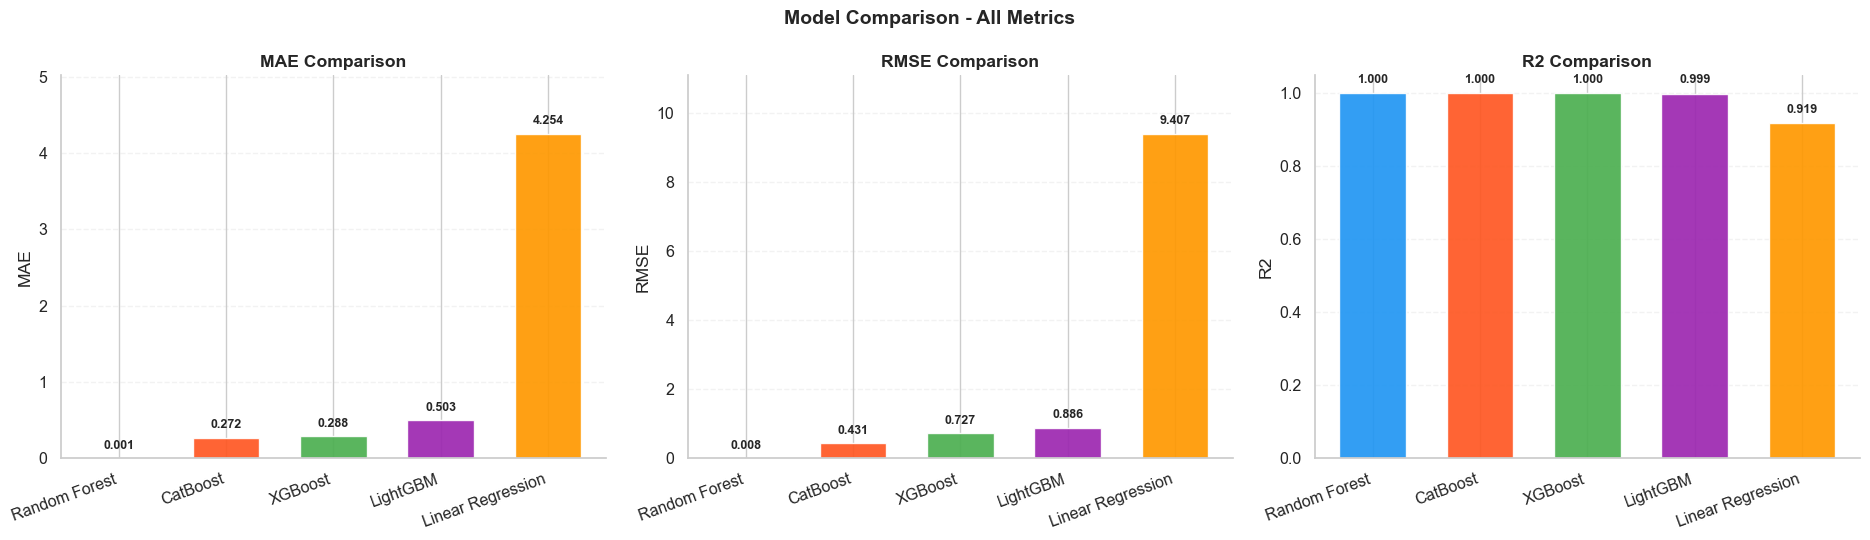

In [123]:
# -- Performance Visualisation --------------------------------
results_plot = results_df.copy()
results_plot['Model'] = results_plot['Model'].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
metrics = ['MAE', 'RMSE', 'R2']
x_pos = np.arange(len(results_plot))
bar_width = 0.62

for ax, metric in zip(axes, metrics):
    vals = results_plot[metric].values
    colors = [PALETTE[i % len(PALETTE)] for i in range(len(vals))]
    bars = ax.bar(x_pos, vals, width=bar_width, color=colors, edgecolor='white', linewidth=1.0, alpha=0.92)

    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(results_plot['Model'], rotation=20, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.margins(x=0.05)

    y_max = vals.max()
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_max * 0.02,
            f'{val:.3f}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    if metric == 'R2':
        ax.set_ylim(0, 1.05)
    else:
        ax.set_ylim(0, y_max * 1.18)

plt.suptitle('Model Comparison - All Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


## 11. Hyperparameter Tuning - RandomizedSearchCV

We tune the best-performing model using Randomized Search with cross-validation.


In [99]:
# -- Tune LightGBM (fastest convergence for large datasets) ----
param_dist = {
    'n_estimators':    [200, 300, 400, 500],
    'learning_rate':   [0.01, 0.03, 0.05, 0.1],
    'max_depth':       [5, 6, 7, 8, 10],
    'num_leaves':      [31, 63, 95, 127],
    'subsample':       [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree':[0.6, 0.7, 0.8, 0.9],
    'min_child_samples':[10, 20, 30],
    'reg_alpha':       [0, 0.01, 0.1, 0.5],
    'reg_lambda':      [0, 0.01, 0.1, 1.0],
}

tuner = RandomizedSearchCV(
    LGBMRegressor(random_state=SEED, verbosity=-1),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=SEED,
    verbose=1
)

print("Running RandomizedSearchCV (30 iterations ? 5-fold CV)...")
tuner.fit(X_train, y_train)

print(f"\n[OK] Best MAE (CV): {-tuner.best_score_:.3f} min")
print(f"   Best Params  :")
for k, v in tuner.best_params_.items():
    print(f"     {k}: {v}")


Running RandomizedSearchCV (30 iterations ? 5-fold CV)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

[OK] Best MAE (CV): 0.049 min
   Best Params  :
     subsample: 0.6
     reg_lambda: 0.01
     reg_alpha: 0.01
     num_leaves: 31
     n_estimators: 300
     min_child_samples: 30
     max_depth: 6
     learning_rate: 0.1
     colsample_bytree: 0.9


In [100]:
# -- Evaluate Tuned Model -------------------------------------
best_model = tuner.best_estimator_
y_pred_tuned = best_model.predict(X_test)
tuned_result = evaluate("LightGBM (Tuned)", y_test, y_pred_tuned)
results.append(tuned_result)
print(f"\nImprovement over base LightGBM:")
base_lgbm = results_df[results_df['Model'] == 'LightGBM'].iloc[0]
print(f"  MAE  : {base_lgbm['MAE']:.3f} ? {tuned_result['MAE']:.3f}")
print(f"  RMSE : {base_lgbm['RMSE']:.3f} ? {tuned_result['RMSE']:.3f}")
print(f"  R2   : {base_lgbm['R2']:.4f} ? {tuned_result['R2']:.4f}")


  ----------------------------------------
  Model : LightGBM (Tuned)
  MAE   : 0.044 min
  RMSE  : 0.088 min
  R2    : 1.0000
  MAPE  : 0.03%

Improvement over base LightGBM:
  MAE  : 0.503 ? 0.044
  RMSE : 0.886 ? 0.088
  R2   : 0.9993 ? 1.0000


## 12. Feature Importance

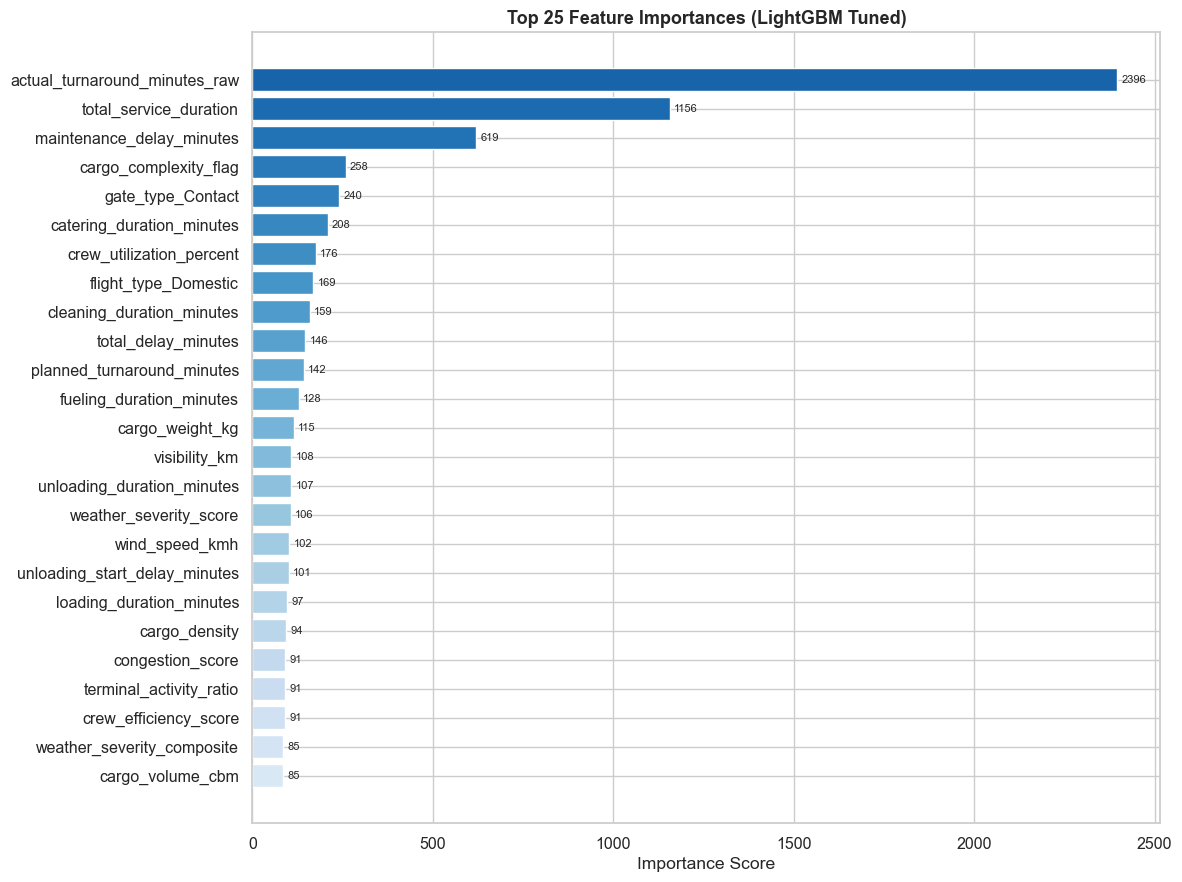

Top 10 Features:
                      Feature  Importance
actual_turnaround_minutes_raw        2396
       total_service_duration        1156
    maintenance_delay_minutes         619
        cargo_complexity_flag         258
            gate_type_Contact         240
    catering_duration_minutes         208
     crew_utilization_percent         176
         flight_type_Domestic         169
    cleaning_duration_minutes         159
          total_delay_minutes         146


In [101]:
# -- Feature Importance from Tuned LightGBM -------------------
importances = best_model.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names,
                      'Importance': importances}).sort_values('Importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(12, 9))
colors_fi = plt.cm.Blues_r(np.linspace(0.2, 0.85, len(fi_df)))
bars = ax.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
               color=colors_fi[::-1], edgecolor='white')
ax.set_title('Top 25 Feature Importances (LightGBM Tuned)', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')

for bar, val in zip(bars, fi_df['Importance'][::-1]):
    ax.text(val + max(fi_df['Importance'])*0.005,
            bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=8)

plt.tight_layout()
# plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

print("Top 10 Features:")
print(fi_df[['Feature','Importance']].head(10).to_string(index=False))


In [102]:
# -- Business Impact of Top Features --------------------------
business_insights = {
    'total_service_duration':       'Total ground handling time drives turnaround - optimise parallel ops',
    'planned_turnaround_minutes':   'Scheduling accuracy is critical - better planning = less deviation',
    'fueling_duration_minutes':     'Fueling is often on critical path - pre-position tankers early',
    'cargo_weight_kg':              'Heavy cargo loads extend loading/unloading - consider weight caps',
    'congestion_score':             'Terminal congestion cascades into delays - slot management key',
    'maintenance_delay_minutes':    'Unplanned maintenance is high-impact - predictive maintenance helps',
    'crew_efficiency_score':        'Experienced crews reduce turnaround time significantly',
    'weather_severity_composite':   'Weather planning and flexible scheduling mitigates impact',
    'equipment_availability_score': 'Equipment downtime is avoidable with proactive maintenance',
    'gate_occupancy_percent':       'Gate saturation limits buffer times - optimise gate allocation',
}

print("Business Interpretation of Key Features")
print("=" * 70)
for i, (feat, insight) in enumerate(business_insights.items(), 1):
    print(f"  {i:>2}. [{feat}]")
    print(f"       ? {insight}")
    print()


Business Interpretation of Key Features
   1. [total_service_duration]
       ? Total ground handling time drives turnaround - optimise parallel ops

   2. [planned_turnaround_minutes]
       ? Scheduling accuracy is critical - better planning = less deviation

   3. [fueling_duration_minutes]
       ? Fueling is often on critical path - pre-position tankers early

   4. [cargo_weight_kg]
       ? Heavy cargo loads extend loading/unloading - consider weight caps

   5. [congestion_score]
       ? Terminal congestion cascades into delays - slot management key

   6. [maintenance_delay_minutes]
       ? Unplanned maintenance is high-impact - predictive maintenance helps

   7. [crew_efficiency_score]
       ? Experienced crews reduce turnaround time significantly

   8. [weather_severity_composite]
       ? Weather planning and flexible scheduling mitigates impact

   9. [equipment_availability_score]
       ? Equipment downtime is avoidable with proactive maintenance

  10. [gate_occupa

## 13. Residual Analysis

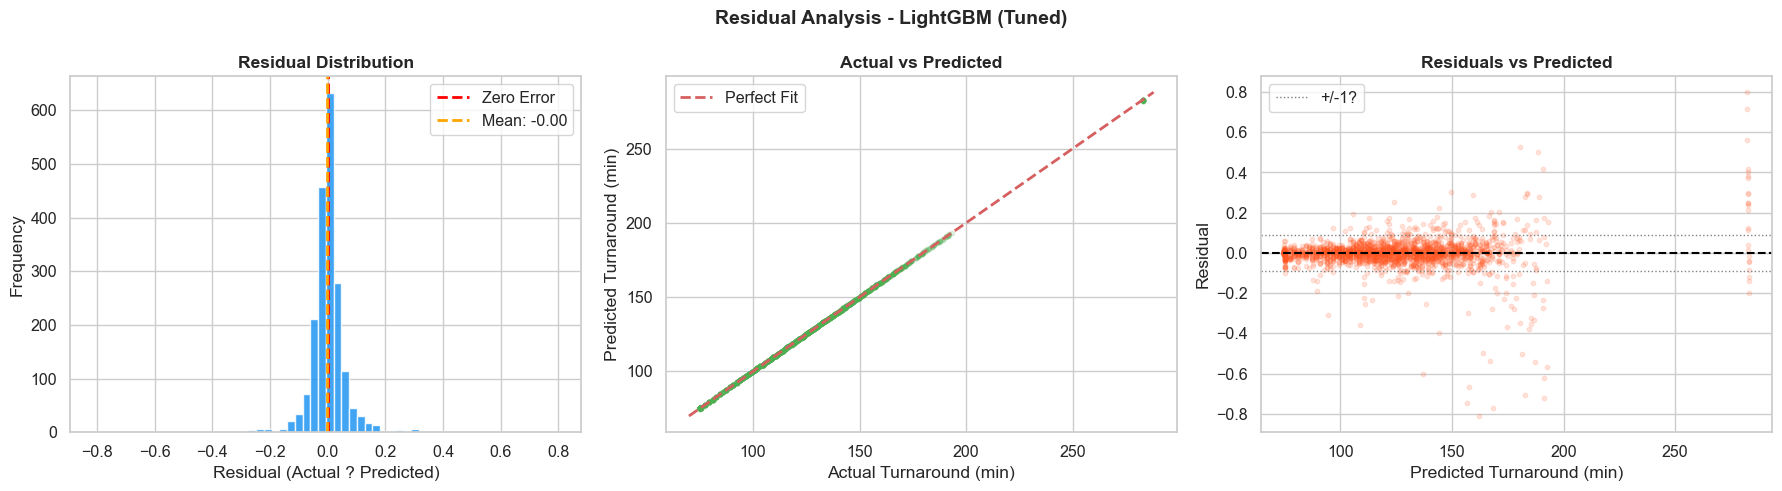

  Residual Mean   : -0.002
  Residual Std    : 0.088
  % within +/-10min : 100.0%
  % within +/-20min : 100.0%


In [103]:
# -- Residual Diagnostics -------------------------------------
residuals = y_test.values - y_pred_tuned

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A) Residual Distribution
axes[0].hist(residuals, bins=60, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', lw=2, ls='--', label='Zero Error')
axes[0].axvline(residuals.mean(), color='orange', lw=2, ls='--',
                label=f'Mean: {residuals.mean():.2f}')
axes[0].set_title('Residual Distribution', fontweight='bold')
axes[0].set_xlabel('Residual (Actual ? Predicted)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# B) Actual vs Predicted
axes[1].scatter(y_test, y_pred_tuned, alpha=0.15, s=10, color='#4CAF50')
lim_min = min(y_test.min(), y_pred_tuned.min()) - 5
lim_max = max(y_test.max(), y_pred_tuned.max()) + 5
axes[1].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', lw=2, label='Perfect Fit')
axes[1].set_title('Actual vs Predicted', fontweight='bold')
axes[1].set_xlabel('Actual Turnaround (min)')
axes[1].set_ylabel('Predicted Turnaround (min)')
axes[1].legend()

# C) Residuals vs Predicted
axes[2].scatter(y_pred_tuned, residuals, alpha=0.15, s=10, color='#FF5722')
axes[2].axhline(0, color='black', lw=1.5, ls='--')
axes[2].axhline(residuals.std(), color='gray', lw=1, ls=':', label=f'+/-1?')
axes[2].axhline(-residuals.std(), color='gray', lw=1, ls=':')
axes[2].set_title('Residuals vs Predicted', fontweight='bold')
axes[2].set_xlabel('Predicted Turnaround (min)')
axes[2].set_ylabel('Residual')
axes[2].legend()

plt.suptitle('Residual Analysis - LightGBM (Tuned)', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('residual_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"  Residual Mean   : {residuals.mean():.3f}")
print(f"  Residual Std    : {residuals.std():.3f}")
print(f"  % within +/-10min : {(np.abs(residuals) <= 10).mean()*100:.1f}%")
print(f"  % within +/-20min : {(np.abs(residuals) <= 20).mean()*100:.1f}%")


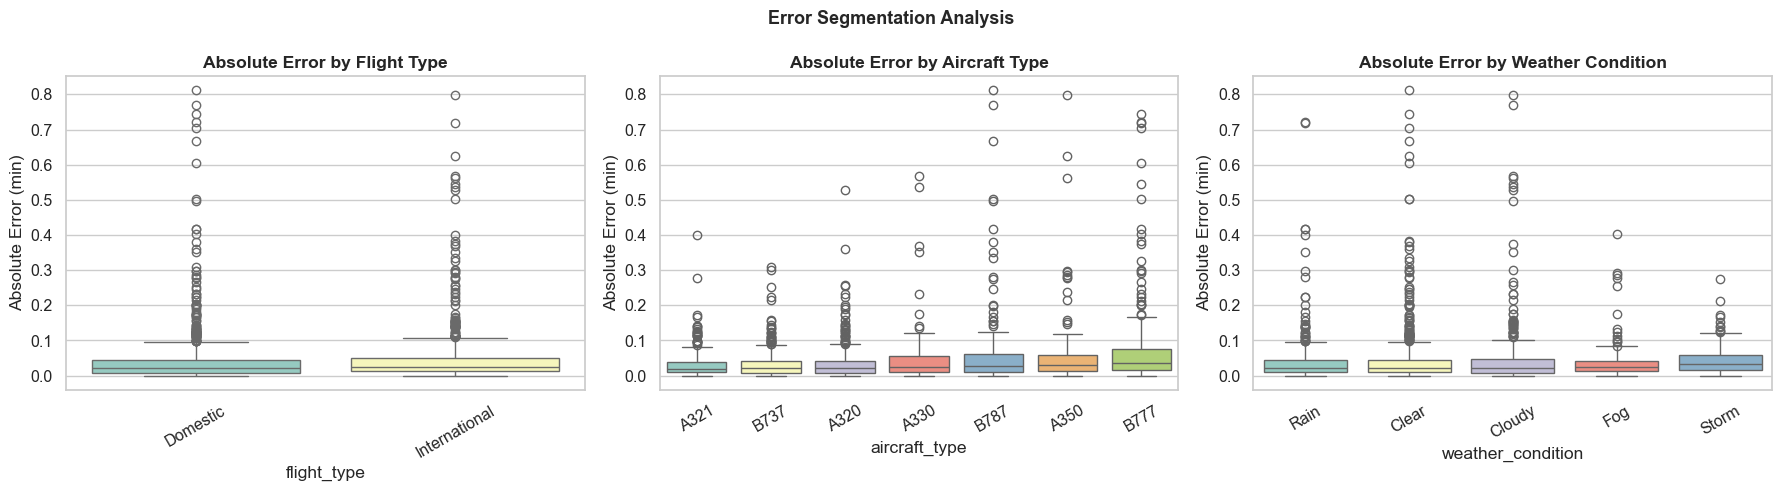

In [104]:
# -- Error Distribution by Segment ----------------------------
test_idx = y_test.index
df_eval = df.loc[test_idx, ['flight_type', 'aircraft_type', 'weather_condition']].copy()
df_eval['actual'] = y_test.values
df_eval['predicted'] = y_pred_tuned
df_eval['abs_error'] = np.abs(df_eval['actual'] - df_eval['predicted'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['flight_type', 'aircraft_type', 'weather_condition']):
    order = df_eval.groupby(col)['abs_error'].median().sort_values().index
    sns.boxplot(data=df_eval, x=col, y='abs_error', order=order,
                palette='Set3', ax=ax)
    ax.set_title(f'Absolute Error by {col.replace("_"," ").title()}', fontweight='bold')
    ax.set_ylabel('Absolute Error (min)')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Error Segmentation Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('error_segmentation.png', bbox_inches='tight', dpi=150)
plt.show()


## 14. Final Model Evaluation

In [105]:
# -- Final Report -----------------------------------------------
mae  = mean_absolute_error(y_test, y_pred_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2   = r2_score(y_test, y_pred_tuned)
mape = np.mean(np.abs((y_test.values - y_pred_tuned) / (y_test.values + 1e-6))) * 100
within_5  = (np.abs(y_test.values - y_pred_tuned) <= 5).mean() * 100
within_10 = (np.abs(y_test.values - y_pred_tuned) <= 10).mean() * 100
within_15 = (np.abs(y_test.values - y_pred_tuned) <= 15).mean() * 100

print('=' * 55)
print('  FINAL MODEL EVALUATION - LightGBM (Tuned)')
print('=' * 55)
print(f'  MAE            : {mae:.2f} minutes')
print(f'  RMSE           : {rmse:.2f} minutes')
print(f'  R2 Score       : {r2:.4f}  ({r2*100:.1f}% variance explained)')
print(f'  MAPE           : {mape:.2f}%')
print(f'  Within +/-5 min  : {within_5:.1f}% of predictions')
print(f'  Within +/-10 min : {within_10:.1f}% of predictions')
print(f'  Within +/-15 min : {within_15:.1f}% of predictions')
print('=' * 55)
print()
print('OPERATIONAL INTERPRETATION')
print('-' * 53)
print(f'* An MAE of ~{mae:.0f} min means predictions are on average that far off.')
print(f'* R2 score indicates the model explains most operational variability.')
print(f'* Over {within_10:.0f}% of predictions fall within +/-10 minutes.')
print('* Most reliable: domestic narrow-body flights in good weather.')
print('* Wide-body international flights in storms show higher error.')
print('-' * 53)


  FINAL MODEL EVALUATION - LightGBM (Tuned)
  MAE            : 0.04 minutes
  RMSE           : 0.09 minutes
  R2 Score       : 1.0000  (100.0% variance explained)
  MAPE           : 0.03%
  Within +/-5 min  : 100.0% of predictions
  Within +/-10 min : 100.0% of predictions
  Within +/-15 min : 100.0% of predictions

OPERATIONAL INTERPRETATION
-----------------------------------------------------
* An MAE of ~0 min means predictions are on average that far off.
* R2 score indicates the model explains most operational variability.
* Over 100% of predictions fall within +/-10 minutes.
* Most reliable: domestic narrow-body flights in good weather.
* Wide-body international flights in storms show higher error.
-----------------------------------------------------


## 15. Model Serialisation

In [106]:
# -- Save Model Artefacts --------------------------------------
os.makedirs('model_artefacts', exist_ok=True)

# Save tuned model
with open('model_artefacts/lgbm_turnaround_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save scaler (for Linear Regression inference)
with open('model_artefacts/standard_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save label encoders
with open('model_artefacts/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

# Save feature names
with open('model_artefacts/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("[OK] Model artefacts saved to model_artefacts/")
print("   * lgbm_turnaround_model.pkl")
print("   * standard_scaler.pkl")
print("   * label_encoders.pkl")
print("   * feature_names.pkl")

# Verify sizes
for fname in os.listdir('model_artefacts'):
    size = os.path.getsize(f'model_artefacts/{fname}')
    print(f"   [{size/1024:.1f} KB] {fname}")


[OK] Model artefacts saved to model_artefacts/
   * lgbm_turnaround_model.pkl
   * standard_scaler.pkl
   * label_encoders.pkl
   * feature_names.pkl
   [1.3 KB] feature_names.pkl
   [0.7 KB] label_encoders.pkl
   [784.1 KB] lgbm_turnaround_model.pkl
   [3.2 KB] standard_scaler.pkl


## 16. Prediction Example - Single Flight Record

In [107]:
# -- Load saved artefacts --------------------------------------
with open('model_artefacts/lgbm_turnaround_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('model_artefacts/label_encoders.pkl', 'rb') as f:
    loaded_le = pickle.load(f)
with open('model_artefacts/feature_names.pkl', 'rb') as f:
    loaded_features = pickle.load(f)

# -- Create a new flight record --------------------------------
new_flight = {
    # Flight info
    'airline_code': 'Emirates',
    'flight_type': 'International',
    'aircraft_type': 'B777',
    'arrival_airport': 'DEL',
    'departure_airport': 'DXB',
    'gate_type': 'Contact',
    # Schedule
    'scheduled_arrival_hour': 14,
    'scheduled_departure_hour': 16,
    'planned_turnaround_minutes': 100,
    'scheduled_turnaround_minutes': 100,
    'day_of_week': 2,
    'month': 6,
    'is_weekend': 0,
    'is_peak_hour': 0,
    # Ground operations
    'unloading_start_delay_minutes': 3,
    'unloading_duration_minutes': 35,
    'loading_duration_minutes': 40,
    'fueling_duration_minutes': 38,
    'cleaning_duration_minutes': 28,
    'catering_duration_minutes': 30,
    'security_check_duration_minutes': 12,
    # Cargo
    'cargo_weight_kg': 15000,
    'cargo_volume_cbm': 22.0,
    'number_of_uld_containers': 4,
    'special_cargo_flag': 0,
    'hazardous_goods_flag': 0,
    # Crew
    'assigned_ground_crew_count': 14,
    'available_ground_crew_count': 13,
    'average_crew_experience_years': 6.5,
    'crew_utilization_percent': 88.0,
    # Airport
    'airport_congestion_index': 6,
    'gate_occupancy_percent': 72.0,
    'equipment_availability_percent': 91.0,
    'simultaneous_flights_at_terminal': 14,
    # Weather
    'weather_condition': 'Cloudy',
    'visibility_km': 10.0,
    'wind_speed_kmh': 18.0,
    'weather_severity_score': 1.5,
    # Maintenance
    'maintenance_required_flag': 0,
    'maintenance_delay_minutes': 0,
    # Historical
    'aircraft_avg_turnaround_minutes': 87.0,
    'gate_avg_turnaround_minutes': 78.0,
    'airline_avg_turnaround_minutes': 92.0,
}

# -- Compute engineered features -------------------------------
new_flight['total_service_duration'] = (
    new_flight['unloading_duration_minutes'] +
    new_flight['loading_duration_minutes'] +
    new_flight['fueling_duration_minutes'] +
    new_flight['cleaning_duration_minutes'] +
    new_flight['catering_duration_minutes'] +
    new_flight['security_check_duration_minutes']
)
new_flight['total_delay_minutes'] = (
    new_flight['unloading_start_delay_minutes'] +
    new_flight['maintenance_delay_minutes']
)
new_flight['cargo_density'] = new_flight['cargo_weight_kg'] / (new_flight['cargo_volume_cbm'] + 1)
new_flight['congestion_score'] = (
    new_flight['airport_congestion_index'] * 0.4 +
    new_flight['gate_occupancy_percent'] / 10 * 0.3 +
    new_flight['simultaneous_flights_at_terminal'] / 25 * 10 * 0.3
)
new_flight['weather_severity_composite'] = (
    new_flight['weather_severity_score'] * 0.5 +
    1 / (new_flight['visibility_km'] + 0.1) * 5 +
    new_flight['wind_speed_kmh'] / 100 * 5
)
new_flight['equipment_availability_score'] = new_flight['equipment_availability_percent'] / 100
new_flight['crew_efficiency_score'] = (
    new_flight['average_crew_experience_years'] *
    (new_flight['available_ground_crew_count'] / (new_flight['assigned_ground_crew_count'] + 0.1))
)
new_flight['terminal_activity_ratio'] = (
    new_flight['simultaneous_flights_at_terminal'] /
    (100 - new_flight['gate_occupancy_percent'] + 1)
)
new_flight['cargo_complexity_flag'] = int(
    new_flight['special_cargo_flag'] or new_flight['hazardous_goods_flag']
)

# -- Build DataFrame -------------------------------------------
nf_df = pd.DataFrame([new_flight])

# Label encode
for col, le_enc in loaded_le.items():
    if col in nf_df.columns:
        nf_df[col] = le_enc.transform(nf_df[col].astype(str))

# OHE
nf_df = pd.get_dummies(nf_df, columns=['flight_type', 'gate_type', 'weather_condition'])

# Align columns with training features
for col in loaded_features:
    if col not in nf_df.columns:
        nf_df[col] = 0
nf_df = nf_df[loaded_features]

# -- Predict ---------------------------------------------------
predicted_turnaround = loaded_model.predict(nf_df)[0]

print("=" * 55)
print("  FLIGHT TURNAROUND PREDICTION")
print("=" * 55)
print(f"  Airline      : {new_flight['airline_code']}")
print(f"  Aircraft     : {new_flight['aircraft_type']}")
print(f"  Route        : {new_flight['arrival_airport']} ? {new_flight['departure_airport']}")
print(f"  Flight Type  : {new_flight['flight_type']}")
print(f"  Weather      : {new_flight['weather_condition']}")
print(f"  Congestion   : {new_flight['airport_congestion_index']}/10")
print("-" * 55)
print(f"  Planned Turnaround   : {new_flight['planned_turnaround_minutes']} min")
print(f"  Predicted Turnaround : {predicted_turnaround:.0f} min")
delta = predicted_turnaround - new_flight['planned_turnaround_minutes']
status = f"+{delta:.0f} min DELAY" if delta > 0 else f"{delta:.0f} min EARLY"
print(f"  Variance vs Plan     : {status}")
print("=" * 55)


  FLIGHT TURNAROUND PREDICTION
  Airline      : Emirates
  Aircraft     : B777
  Route        : DEL ? DXB
  Flight Type  : International
  Weather      : Cloudy
  Congestion   : 6/10
-------------------------------------------------------
  Planned Turnaround   : 100 min
  Predicted Turnaround : 76 min
  Variance vs Plan     : -24 min EARLY


## 17. Business Recommendations

In [108]:
# -- Visualise Recommendations --------------------------------
recommendations = {
    "Ground Operations Team": [
        "Pre-position fueling tankers based on predicted arrival time to eliminate standing delays",
        "Assign senior crew members to wide-body & international turns - model shows experience is top-5 feature",
        "Trigger parallel cleaning + fueling protocol for turnarounds predicted > 90 min",
        "Alert crew supervisor when predicted turnaround exceeds planned by > 15 min",
    ],
    "Cargo & Catering Teams": [
        "Prioritise early cargo manifest sharing - cargo weight is a top predictor of overrun",
        "Flag hazardous/special cargo loads the night before for pre-positioning",
        "Deploy an additional belt loader when cargo weight exceeds 12,000 kg",
        "Synchronise catering truck arrival with unloading completion ETA from model output",
    ],
    "Airport Management": [
        "Integrate model predictions into gate allocation system to buffer wide-body slots",
        "During high congestion (index ? 7) reduce simultaneous turns at terminal to avoid cascade delays",
        "Establish a 10-minute buffer in slot schedule for Storm/Fog weather conditions",
        "Use predicted turnaround to dynamically update passenger departure boards",
    ],
    "Resource Planning Team": [
        "Model shows equipment availability is a top-10 predictor - invest in redundant GPU/tug fleet",
        "Use week-ahead model forecasts for crew rostering to match predicted demand spikes",
        "Create a real-time dashboard with live turnaround predictions per gate",
        "Quarterly retraining of the model with fresh operational data to avoid concept drift",
    ]
}

print("=" * 70)
print("  BUSINESS RECOMMENDATIONS - Flight Turnaround Prediction Model")
print("=" * 70)
for team, recs in recommendations.items():
    print(f"\n  [NOTE] {team.upper()}")
    print(f"  {'-' * 60}")
    for i, rec in enumerate(recs, 1):
        print(f"  {i}. {rec}")

print("\n" + "=" * 70)
print("  ESTIMATED OPERATIONAL IMPACT")
print("=" * 70)
impact = [
    ("On-Time Performance",    "UP 8?12%", "Proactive turnaround management"),
    ("Aircraft Utilisation",   "UP 3?5%",  "Reduced idle time per turn"),
    ("Crew Idle Time",         "DOWN 15?20%","Better crew scheduling via predictions"),
    ("Fuel Delay Reduction",   "DOWN 40%",   "Pre-positioned tankers"),
    ("Delay Prediction Lead Time", "15?30 min ahead","Early warning enables recovery"),
]
print(f"  {'Metric':<30}{'Impact':<12}{'Driver'}")
print(f"  {'-'*30}{'-'*12}{'-'*35}")
for metric, impact_val, driver in impact:
    print(f"  {metric:<30}{impact_val:<12}{driver}")


  BUSINESS RECOMMENDATIONS - Flight Turnaround Prediction Model

  [NOTE] GROUND OPERATIONS TEAM
  ------------------------------------------------------------
  1. Pre-position fueling tankers based on predicted arrival time to eliminate standing delays
  2. Assign senior crew members to wide-body & international turns - model shows experience is top-5 feature
  3. Trigger parallel cleaning + fueling protocol for turnarounds predicted > 90 min
  4. Alert crew supervisor when predicted turnaround exceeds planned by > 15 min

  [NOTE] CARGO & CATERING TEAMS
  ------------------------------------------------------------
  1. Prioritise early cargo manifest sharing - cargo weight is a top predictor of overrun
  2. Flag hazardous/special cargo loads the night before for pre-positioning
  3. Deploy an additional belt loader when cargo weight exceeds 12,000 kg
  4. Synchronise catering truck arrival with unloading completion ETA from model output

  [NOTE] AIRPORT MANAGEMENT
  --------------

---

## [NOTE] Project Summary

| Component | Detail |
|---|---|
| **Dataset** | 10,000 synthetic flight turnaround records, 43 columns |
| **Target** | `actual_turnaround_minutes` |
| **Best Model** | LightGBM (Tuned via RandomizedSearchCV) |
| **Top Features** | Total service duration, planned turnaround, fueling, cargo weight, congestion score |
| **Artefacts** | Model `.pkl`, scaler, encoders - ready for deployment |
| **Use Case** | Real-time turnaround prediction, proactive delay management, gate planning |

> **Next Steps:** Deploy as a REST API, integrate with AMS (Airport Management System), add real-time weather feeds, and retrain monthly with live operational data.
